# 🏗️ Building Age Classification from Satellite Imagery

# Notebook 2 — Reading & Understanding the Data

---

## 2.1 Setup & Imports

In [2]:
# Running locally — no Colab drive mount needed.
# On Google Colab, uncomment the two lines below first:
# from google.colab import drive
# drive.mount('/content/drive')


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────────
# Set DATA_DIR to the folder containing the parquet files.
# When running from the notebooks/ subfolder, '../data' is correct.
DATA_DIR            = "../data"
MADRID_TRAIN_PATH   = f"{DATA_DIR}/madrid_train.parquet"
AMSTERDAM_DATA_PATH = f"{DATA_DIR}/amsterdam_data.parquet"

# ── Constants ──────────────────────────────────────────────────────────────────
BASE_BANDS = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

# City-specific class 1/2 boundary year (Notebook 1, Section 1.4)
CLASS_EVENTS = {'Amsterdam': 1945, 'Madrid': 1960}

CLASS_COLORS = {1: '#4393c3', 2: '#2ca25f', 3: '#fd8d3c', 4: '#de2d26'}
CLASS_LABELS = {
    'Amsterdam': {1: 'Pre-1945',  2: '1945-1984', 3: '1984-2004', 4: '2004-2024'},
    'Madrid':    {1: 'Pre-1960',  2: '1960-1984', 3: '1984-2004', 4: '2004-2024'},
}

plt.rcParams['figure.dpi'] = 100
print("Setup complete.")


Setup complete.


---

## 2.2 Load the Data

The dataset is stored in **Parquet format** — a column-oriented binary format that loads
much faster than CSV for large tables.

The wide-format layout means each row represents **one geographic pixel location in one
year**. Up to 3 Landsat observations from that summer are stored as `obs_1`, `obs_2`,
`obs_3` column groups (sorted earliest to latest by day-of-year within the year).

After loading we derive the `age_class` label from `weighted_mean_year` using the class
boundaries defined in Notebook 1, Section 1.4.


In [4]:
# ── Load training data ─────────────────────────────────────────────────────────
df = pd.read_parquet(MADRID_TRAIN_PATH)
print(f"Loaded: {len(df):,} rows x {df.shape[1]} columns")
print(f"City:      {df['city'].unique().tolist()}")
print(f"Years:     {df['year'].min()} - {df['year'].max()}  ({df['year'].nunique()} distinct years)")
print(f"Locations: {df.groupby(['px_key','py_key']).ngroups:,} unique geographic pixels")

# ── Derive age class from weighted_mean_year ───────────────────────────────────
def assign_age_class(data, events=CLASS_EVENTS):
    out = data.copy()
    out['age_class'] = pd.NA
    for city, ev in events.items():
        mask = out['city'] == city
        if mask.any():
            bins = [-np.inf, ev, 1984, 2004, np.inf]
            out.loc[mask, 'age_class'] = pd.cut(
                out.loc[mask, 'weighted_mean_year'],
                bins=bins, labels=[1, 2, 3, 4]
            ).astype('Int64')
    return out

df = assign_age_class(df)
print(f"\nAge class distribution (rows):")
for cls, n in df['age_class'].value_counts().sort_index().items():
    city = df['city'].iloc[0]
    lbl = CLASS_LABELS.get(city, CLASS_LABELS['Madrid']).get(int(cls), '')
    print(f"  Class {cls} ({lbl}): {n:,}")


Loaded: 3,172,765 rows x 48 columns
City:      ['Madrid']
Years:     1984 - 2025  (42 distinct years)
Locations: 76,263 unique geographic pixels

Age class distribution (rows):
  Class 1 (Pre-1960): 576,190
  Class 2 (1960–1984): 1,125,456
  Class 3 (1984–2004): 780,886
  Class 4 (2004–2024): 690,233


In [5]:
# Wide format: show metadata + obs_1 columns (obs_2 and obs_3 follow the same pattern)
meta_cols = ['pixel_id', 'city', 'year', 'px_key', 'py_key',
             'coverage', 'weighted_mean_year', 'age_class']
obs1_cols = [c for c in df.columns if c.endswith('_1')]
df[meta_cols + obs1_cols].head()


,pixel_id,city,year,px_key,py_key,coverage,weighted_mean_year,age_class,Blue_1,Green_1,Red_1,NIR_1,SWIR1_1,SWIR2_1,QA_PIXEL_1,QA_RADSAT_1,doy_1,scene_id_1,dataset_1,qa_valid_1
0,Madrid_14194_149671_1984,Madrid,1984,14194,149671,0.15,2014.000000,4,9184.207031,9821.585938,10537.317383,15736.041016,16615.345703,13306.133789,5440,0,199,LT05_L2SP_201032_19840717_20200918_02_T1,landsat_tm_c2_l2,True
1,Madrid_14196_149670_1984,Madrid,1984,14196,149670,0.17,2014.000000,4,9513.961914,10631.701172,11703.544922,17431.326172,18064.712891,14072.572266,5440,0,199,LT05_L2SP_201032_19840717_20200918_02_T1,landsat_tm_c2_l2,True
2,Madrid_14259_149645_1984,Madrid,1984,14259,149645,0.49,1950.000000,1,10933.764648,12355.941406,14021.262695,18071.968750,18510.203125,16110.348633,5440,0,199,LT05_L2SP_201032_19840717_20200918_02_T1,landsat_tm_c2_l2,True
3,Madrid_14268_149501_1984,Madrid,1984,14268,149501,0.28,1920.000000,1,10224.352539,11437.046875,12968.022461,17290.304688,20047.041016,16108.329102,5440,0,199,LT05_L2SP_201032_19840717_20200918_02_T1,landsat_tm_c2_l2,True
4,Madrid_14302_149354_1984,Madrid,1984,14302,149354,0.28,1977.178589,2,11413.229492,12704.223633,14453.562500,18616.919922,19161.146484,16510.228516,5440,0,199,LT05_L2SP_201032_19840717_20200918_02_T1,landsat_tm_c2_l2,True


In [6]:
BLUE_MAX = 15_000  # Atmospheric outlier threshold

def get_best_obs_band(data, band):
    col = np.full(len(data), np.nan)
    for slot in [1, 2, 3]:
        bc = f'{band}_{slot}'
        qc = f'qa_valid_{slot}'
        if bc not in data.columns or qc not in data.columns:
            continue
        valid = data[qc].fillna(False).values
        col = np.where(np.isnan(col) & valid, data[bc].fillna(np.nan).values, col)
    return col

def make_flat_view(data):
    keep = [c for c in ['pixel_id', 'city', 'year', 'px_key', 'py_key',
                        'weighted_mean_year', 'age_class']
            if c in data.columns]
    out = data[keep].copy()
    for band in BASE_BANDS:
        out[band] = get_best_obs_band(data, band)
    out = out.dropna(subset=BASE_BANDS)
    n_before = len(out)
    out = out[out['Blue'] <= BLUE_MAX].copy()
    removed = n_before - len(out)
    if removed:
        city = data['city'].iloc[0] if 'city' in data.columns else ''
        print(f"  [{city}] Removed {removed:,} outlier rows (Blue > {BLUE_MAX:,})")
    return out

df_flat = make_flat_view(df)
print(f"Flat view: {len(df_flat):,} rows with all 6 bands valid "
      f"({len(df_flat)/len(df)*100:.1f}% of original rows)")
df_flat[['city', 'year', 'px_key', 'py_key', 'weighted_mean_year', 'age_class'] + BASE_BANDS].head()


  [Madrid] Removed 34,845 outlier rows (Blue > 15,000)
Flat view: 3,137,920 rows with all 6 bands valid (98.9% of original rows)


,city,year,px_key,py_key,weighted_mean_year,age_class,Blue,Green,Red,NIR,SWIR1,SWIR2
0,Madrid,1984,14194,149671,2014.000000,4,9184.207031,9821.585938,10537.317383,15736.041016,16615.345703,13306.133789
1,Madrid,1984,14196,149670,2014.000000,4,9513.961914,10631.701172,11703.544922,17431.326172,18064.712891,14072.572266
2,Madrid,1984,14259,149645,1950.000000,1,10933.764648,12355.941406,14021.262695,18071.968750,18510.203125,16110.348633
3,Madrid,1984,14268,149501,1920.000000,1,10224.352539,11437.046875,12968.022461,17290.304688,20047.041016,16108.329102
4,Madrid,1984,14302,149354,1977.178589,2,11413.229492,12704.223633,14453.562500,18616.919922,19161.146484,16510.228516


> **Atmospheric outlier removal:** The raw Amsterdam data contains Landsat 7 scenes across many years. Scene `LE07_L2SP_199023_20030529` (29 May 2003 — two days before the Scan Line Corrector failure) has Blue reflectance up to **64,126**, causing the sharp 2003 spike visible in the yearly-mean plots. This contamination is undetected by the standard `qa_valid` filter because QA\_PIXEL bit 2 (cirrus) is not checked. `make_flat_view()` removes all rows where the best-valid Blue exceeds `BLUE_MAX = 15,000`. **Apply the same threshold in Notebook 3** before feature engineering.

In [7]:
# Load Amsterdam transfer dataset — available throughout the notebook from here on
df_ams      = pd.read_parquet(AMSTERDAM_DATA_PATH)
df_ams      = assign_age_class(df_ams)
df_ams_flat = make_flat_view(df_ams)

CITIES = [('Madrid',    df_flat,     df),
          ('Amsterdam', df_ams_flat, df_ams)]

YEAR_MIN = min(flat['year'].min() for _, flat, _ in CITIES)
YEAR_MAX = max(flat['year'].max() for _, flat, _ in CITIES)

print(f"Madrid    : {len(df_flat):,} rows, "
      f"{df_flat.groupby(['px_key','py_key']).ngroups:,} locations")
print(f"Amsterdam : {len(df_ams_flat):,} rows, "
      f"{df_ams_flat.groupby(['px_key','py_key']).ngroups:,} locations")
print(f"Year range: {YEAR_MIN} – {YEAR_MAX}")


  [Amsterdam] Removed 12,917 outlier rows (Blue > 15,000)
Madrid    : 3,137,920 rows, 76,263 locations
Amsterdam : 1,049,960 rows, 25,992 locations
Year range: 1984 – 2025


---

## 2.3 Understanding the Columns

### Wide-format columns (raw parquet)

| Column | Type | Description |
|--------|------|-------------|
| `pixel_id` | str | Unique identifier: `{city}_{px_key}_{py_key}_{year}` |
| `city` | str | `Amsterdam` or `Madrid` |
| `year` | int | Acquisition year |
| `px_key`, `py_key` | int | Geographic grid indices (UTM coordinates / 30 m, rounded). Stable across Landsat path/rows. |
| `pixel_x`, `pixel_y` | float | Pixel centre coordinates in UTM (metres) |
| `coverage` | float | Fraction of pixel area overlapping building footprints (>= 0.15 in this dataset) |
| `weighted_mean_year` | float | Area-weighted mean construction year of overlapping buildings |
| `Blue_N` – `SWIR2_N` | float | Spectral reflectance for observation slot N (N = 1, 2, 3; sorted earliest to latest within the year) |
| `qa_valid_N` | bool | True if observation N is a clean, non-fill, non-cloud pixel |
| `doy_N` | int | Day of year for observation N |
| `scene_id_N` | str | Landsat scene identifier for observation N |
| `dataset_N` | str | Landsat collection (`landsat_tm_c2_l2` = L5, `landsat_ot_c2_l2` = L8/9) |

### Derived columns (added after loading)

| Column | Description |
|--------|-------------|
| `age_class` | Integer 1–4, derived from `weighted_mean_year` using city-specific boundaries (Notebook 1, Section 1.4) |

### Flat view (`df_flat`)

`df_flat` extracts one reflectance value per band per row — the first `qa_valid` observation
(obs_1, else obs_2, else obs_3). This is the version used for all feature exploration and
model input.


---

## 2.4 Building Coverage

The `coverage` column tells us what fraction of each 30 m pixel is covered by building footprints. The dataset has been pre-filtered to pixels with **≥15% building coverage**, so every pixel in this file has a meaningful building age label. Higher coverage generally means a more reliable label.

In [8]:
print(f"Coverage range: {df['coverage'].min():.2f} – {df['coverage'].max():.2f}")
print(f"Mean coverage:  {df['coverage'].mean():.2f}")
print(f"Median coverage: {df['coverage'].median():.2f}")

Coverage range: 0.15 – 1.00
Mean coverage:  0.50
Median coverage: 0.46


#### Coverage distribution

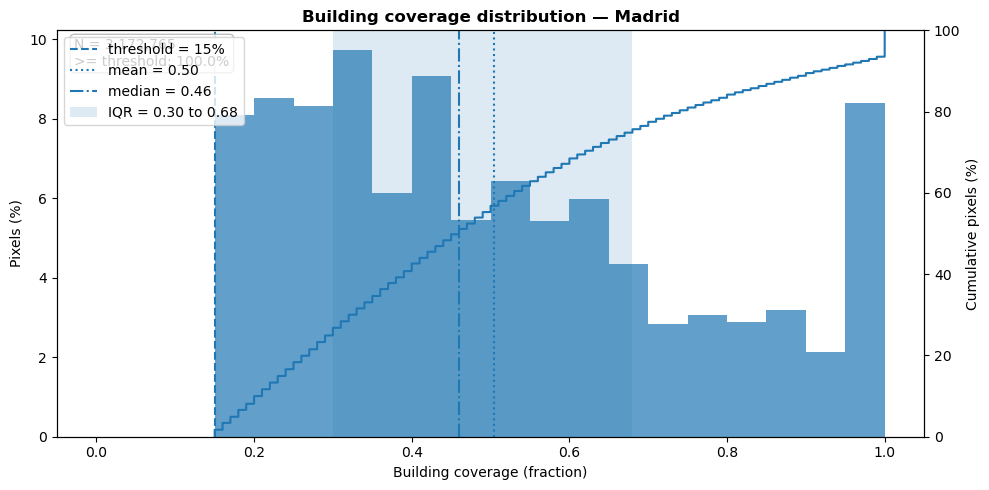

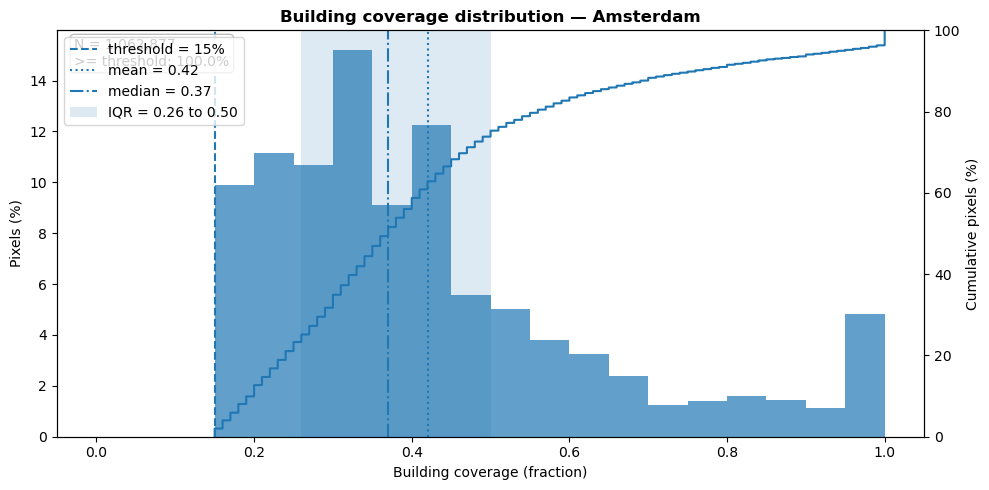

In [9]:
def plot_coverage_distribution(data, title="", coverage_col="coverage",
                                threshold=0.15, bins=20, tol=1e-9):
    x = data[coverage_col].to_numpy()
    x = x[np.isfinite(x)]
    x = np.clip(x, 0, 1)
    if len(x) == 0:
        print("No valid coverage values."); return
    n = len(x)
    mean, median = float(np.mean(x)), float(np.median(x))
    q25, q75 = np.quantile(x, [0.25, 0.75])
    edges   = np.linspace(0, 1, bins + 1)
    weights = np.ones_like(x) / n * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(x, bins=edges, weights=weights, alpha=0.7, edgecolor="none")
    ax.set_xlabel("Building coverage (fraction)")
    ax.set_ylabel("Pixels (%)")
    ax.set_title(f"Building coverage distribution{' — ' + title if title else ''}",
                 fontweight="bold")
    ax.axvline(threshold, linestyle="--", label=f"threshold = {threshold:.0%}")
    ax.axvline(mean,      linestyle=":",  label=f"mean = {mean:.2f}")
    ax.axvline(median,    linestyle="-.", label=f"median = {median:.2f}")
    ax.axvspan(q25, q75,  alpha=0.15,    label=f"IQR = {q25:.2f} to {q75:.2f}")
    ax2 = ax.twinx()
    xs, cdf = np.sort(x), (np.arange(1, n+1) / n) * 100
    ax2.plot(xs, cdf, linewidth=1.5)
    ax2.set_ylabel("Cumulative pixels (%)"); ax2.set_ylim(0, 100)
    ax.text(0.02, 0.98,
            f"N = {n:,}\n>= threshold: {(x >= threshold).mean()*100:.1f}%",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"))
    ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

for city_name, flat, raw in CITIES:
    plot_coverage_distribution(raw, title=city_name, threshold=0.15, bins=20)


---

## 2.5 Age Class Distribution

Let's look at how the 4 age classes are distributed across the dataset.


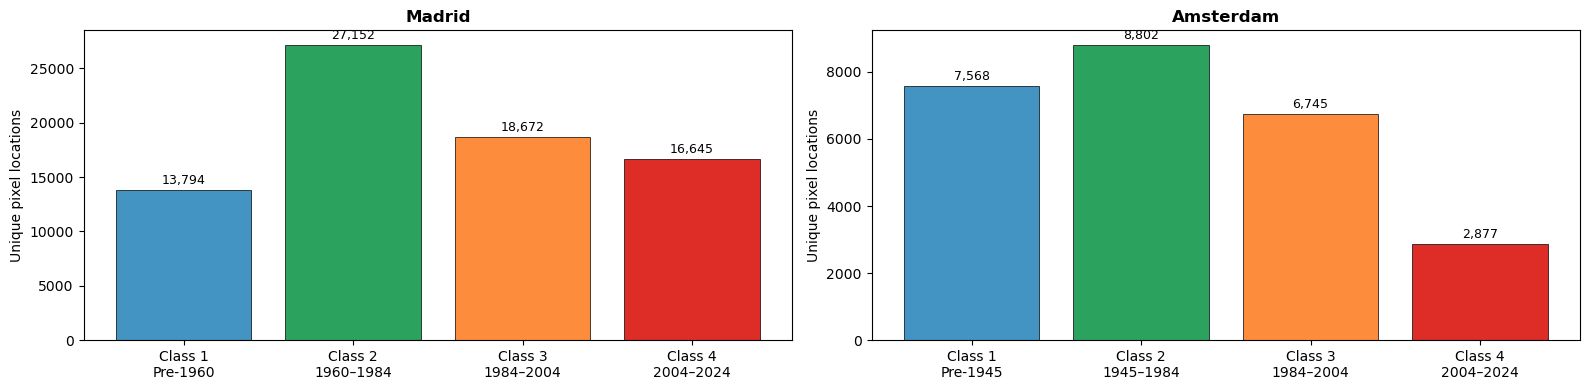

In [10]:
def plot_class_distribution(data, ax=None, title=None):
    city    = data["city"].iloc[0] if "city" in data.columns else "Madrid"
    locs    = data.drop_duplicates(subset=["px_key", "py_key"])
    counts  = locs["age_class"].value_counts().sort_index()
    labels  = CLASS_LABELS.get(city, CLASS_LABELS["Madrid"])
    colors  = [CLASS_COLORS.get(int(c), "grey") for c in counts.index]
    xlabels = ["Class " + str(int(c)) + "\n" + labels.get(int(c), "") for c in counts.index]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(xlabels, counts.values, color=colors, edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + counts.max()*0.01,
                f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Unique pixel locations")
    if title:
        ax.set_title(title, fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (city_name, flat, _) in zip(axes, CITIES):
    plot_class_distribution(flat, ax=ax, title=city_name)
plt.tight_layout(); plt.show()


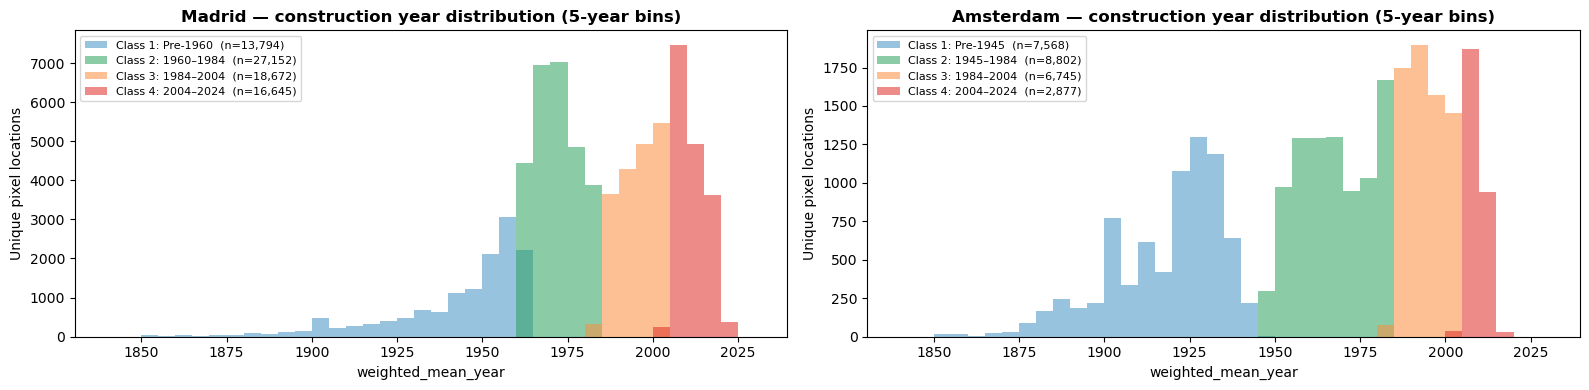

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)
bins = np.arange(1840, 2031, 5)

for ax, (city_name, flat, _) in zip(axes, CITIES):
    df_locs = flat.drop_duplicates(subset=['px_key', 'py_key'])
    labels  = CLASS_LABELS.get(city_name, CLASS_LABELS['Madrid'])
    for cls in [1, 2, 3, 4]:
        subset = df_locs[df_locs['age_class'] == cls]['weighted_mean_year']
        if subset.empty: continue
        lbl = labels.get(cls, f'Class {cls}')
        ax.hist(subset, bins=bins, alpha=0.55, color=CLASS_COLORS[cls],
                label=f'Class {cls}: {lbl}  (n={len(subset):,})')
    ax.set_xlabel('weighted_mean_year')
    ax.set_ylabel('Unique pixel locations')
    ax.set_title(f'{city_name} — construction year distribution (5-year bins)',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


Note the class imbalance — **Class 1** (pre-1960 in Madrid) dominates because pre-modern
buildings make up the majority of the existing city fabric. This imbalance will need to be
addressed during model training (Notebook 3).


---

## 2.6 Time Series: Single-Pixel Trajectories

One of the most distinctive features of this dataset is its temporal depth: up to
**40 years of annual Landsat observations** per geographic pixel. This time series
contains signal relevant to building age:

- Pixels in **Classes 3 and 4** (built during the satellite record, 1984–present)
  may show a reflectance change around the construction year as new building materials
  replace the previous surface.
- Pixels in **Classes 1 and 2** (built before 1984) will not show a construction
  signal — only post-construction ageing and weathering.

### City-specific class boundaries

The class 1/2 boundary reflects a significant construction event in each city's history:

- **Madrid — 1960:** The *Planes de Desarrollo Económico y Social* (Economic and Social
  Development Plans), introduced under the Franco dictatorship in 1959–1960, transformed
  Madrid from a predominantly pre-war brick city into a rapidly industrialising metropolis.
  Mass rural-to-urban migration triggered the first large-scale construction of reinforced
  concrete apartment blocks (*bloques de pisos*) in Madrid's expanding periphery — a
  fundamentally different construction typology, and a different spectral signature,
  from the older brick and stone buildings of the historic centre.

- **Amsterdam — 1945:** The end of the German occupation marks the transition from
  pre-war brick construction (Amsterdam School, interwar expansion) to post-war modernist
  building programmes. The Dutch *wederopbouw* (reconstruction) initiative of the late
  1940s–50s introduced mass-produced concrete prefabrication and rationalist planning,
  producing urban fabric spectrally distinct from pre-war neighbourhoods.

The plots below show the time series of **three representatives pixel from each class**.  The color-coordinated vertical dotted lines for classes 3 and 4 indicate the date of construction for that particular pixel.

The goal of these plots is to determine whether there is any human-discernible difference between the data series associated with the different classes.


In [12]:
def find_best_pixels(data, age_class, n=3):
    """
    Select n pixels for a class with:
      - different construction years (one from each year-tertile of the class)
      - spatial spread (each successive pick maximises min distance to prior picks)
    """
    cls_df = data[(data['age_class'] == int(age_class)) &
                  data['Blue'].notna() &
                  data['weighted_mean_year'].notna()]
    if cls_df.empty:
        return []

    # One row per pixel: observation count + construction year
    pix = (cls_df.groupby(['px_key', 'py_key'])
                 .agg(obs=('Blue', 'count'), yr=('weighted_mean_year', 'first'))
                 .reset_index()
                 .sort_values('yr')
                 .reset_index(drop=True))

    if len(pix) <= n:
        return list(zip(pix['px_key'].astype(int), pix['py_key'].astype(int)))

    # Split into n equal year-tertiles
    size   = len(pix) // n
    groups = [pix.iloc[i * size : len(pix) if i == n - 1 else (i + 1) * size]
              for i in range(n)]

    # Greedy: from each tertile pick the pixel that maximises min distance
    # to already-selected pixels (first pick: most observations)
    selected = []
    for grp in groups:
        if not selected:
            row = grp.nlargest(1, 'obs').iloc[0]
        else:
            coords  = grp[['px_key', 'py_key']].values.astype(float)
            sel_arr = np.array(selected, dtype=float)
            min_d   = np.sqrt(((coords[:, None, :] - sel_arr[None, :, :]) ** 2)
                              .sum(axis=2)).min(axis=1)
            row = grp.iloc[min_d.argmax()]
        selected.append((int(row['px_key']), int(row['py_key'])))

    return selected

def get_pixel_ts(data, px, py, band):
    pix = data[(data['px_key'] == px) & (data['py_key'] == py)].sort_values('year')
    return pix[['year', band, 'age_class']].dropna(subset=[band]).reset_index(drop=True)

class_pixels = {}
for city_name, flat, _ in CITIES:
    class_pixels[city_name] = {}
    for cls in [1, 2, 3, 4]:
        px_list = find_best_pixels(flat, cls, n=3)
        class_pixels[city_name][cls] = px_list
        lbl = CLASS_LABELS.get(city_name, CLASS_LABELS['Madrid']).get(cls, '')
        yrs = [int(round(flat[(flat['px_key'] == px) & (flat['py_key'] == py)]
                         ['weighted_mean_year'].iloc[0]))
               for px, py in px_list]
        dists = []
        for j in range(1, len(px_list)):
            dx = px_list[j][0] - px_list[0][0]
            dy = px_list[j][1] - px_list[0][1]
            dists.append(int(((dx**2 + dy**2) ** 0.5) * 30))  # metres from first pixel
        print(f"{city_name:12s}  Class {cls} ({lbl:12s}): "
              f"years {yrs},  sep >{min(dists) if dists else 0} m")


Madrid        Class 1 (Pre-1960    ): years [1850, 1950, 1960],  sep >14367 m
Madrid        Class 2 (1960–1984   ): years [1960, 1972, 1980],  sep >14696 m
Madrid        Class 3 (1984–2004   ): years [1984, 1998, 2004],  sep >14974 m
Madrid        Class 4 (2004–2024   ): years [2004, 2011, 2014],  sep >18678 m
Amsterdam     Class 1 (Pre-1945    ): years [1850, 1914, 1931],  sep >10442 m
Amsterdam     Class 2 (1945–1984   ): years [1945, 1969, 1975],  sep >9631 m
Amsterdam     Class 3 (1984–2004   ): years [1984, 1993, 1999],  sep >14212 m
Amsterdam     Class 4 (2004–2024   ): years [2004, 2009, 2013],  sep >10103 m


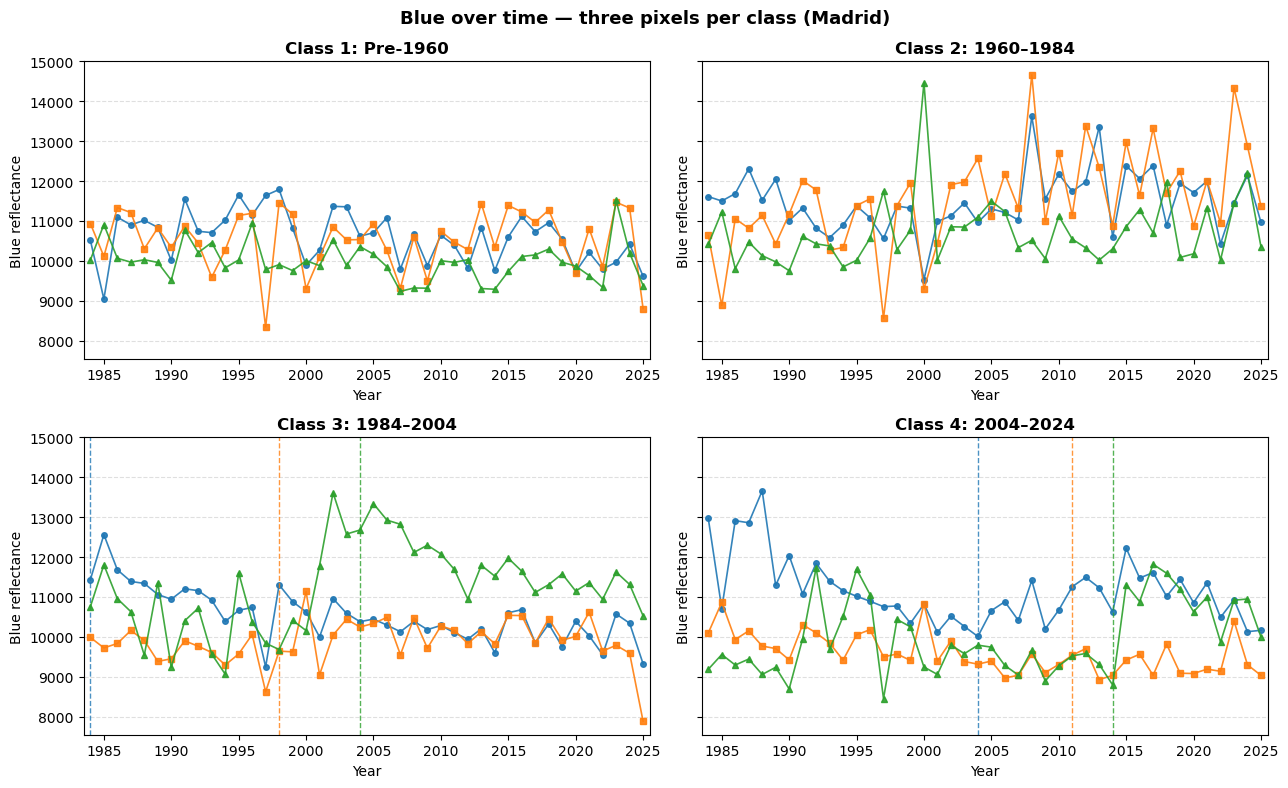

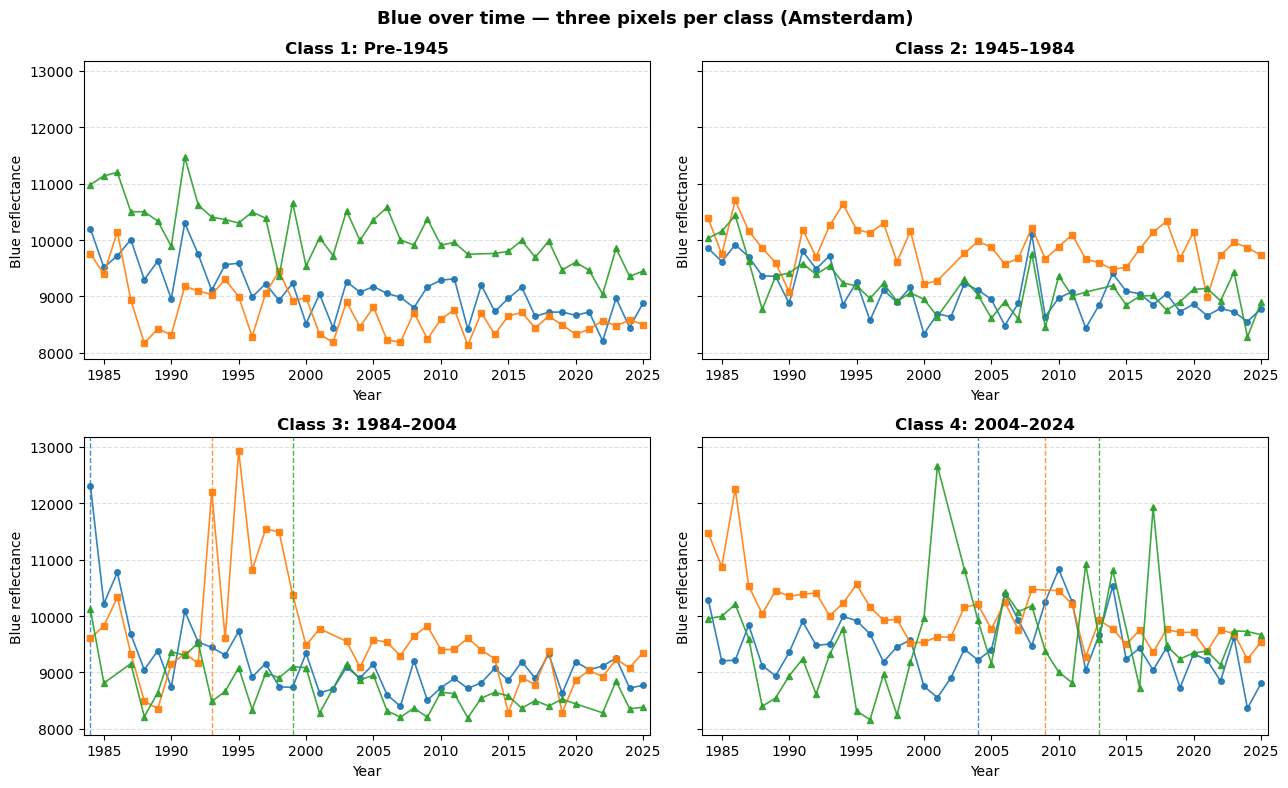

In [13]:
MARKERS      = ["o", "s", "^"]
PIXEL_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # same three colors across all class subplots

def plot_pixel_ts(band, data, pixels):
    city   = data["city"].iloc[0]
    labels = CLASS_LABELS.get(city, CLASS_LABELS["Madrid"])
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
    for ax, cls in zip(axes.flat, [1, 2, 3, 4]):
        px_list = pixels[cls]
        if not px_list:
            ax.set_visible(False); continue
        for i, (px, py) in enumerate(px_list):
            color = PIXEL_COLORS[i]
            ts    = get_pixel_ts(data, px, py, band)
            ax.plot(ts["year"], ts[band], marker=MARKERS[i], markersize=4,
                    color=color, linewidth=1.2, alpha=0.9)
            if cls in [3, 4]:
                yr_rows = data[(data["px_key"] == px) & (data["py_key"] == py)]["weighted_mean_year"]
                if not yr_rows.empty:
                    yr = int(round(yr_rows.iloc[0]))
                    ax.axvline(yr, color=color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.set_xlim(YEAR_MIN - 0.5, YEAR_MAX + 0.5)
        ax.set_title(f"Class {cls}: {labels.get(cls, '')}", fontweight="bold")
        ax.set_xlabel("Year"); ax.set_ylabel(f"{band} reflectance")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.suptitle(f"{band} over time — three pixels per class ({city})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

for city_name, flat, _ in CITIES:
    plot_pixel_ts("Blue", flat, class_pixels[city_name])


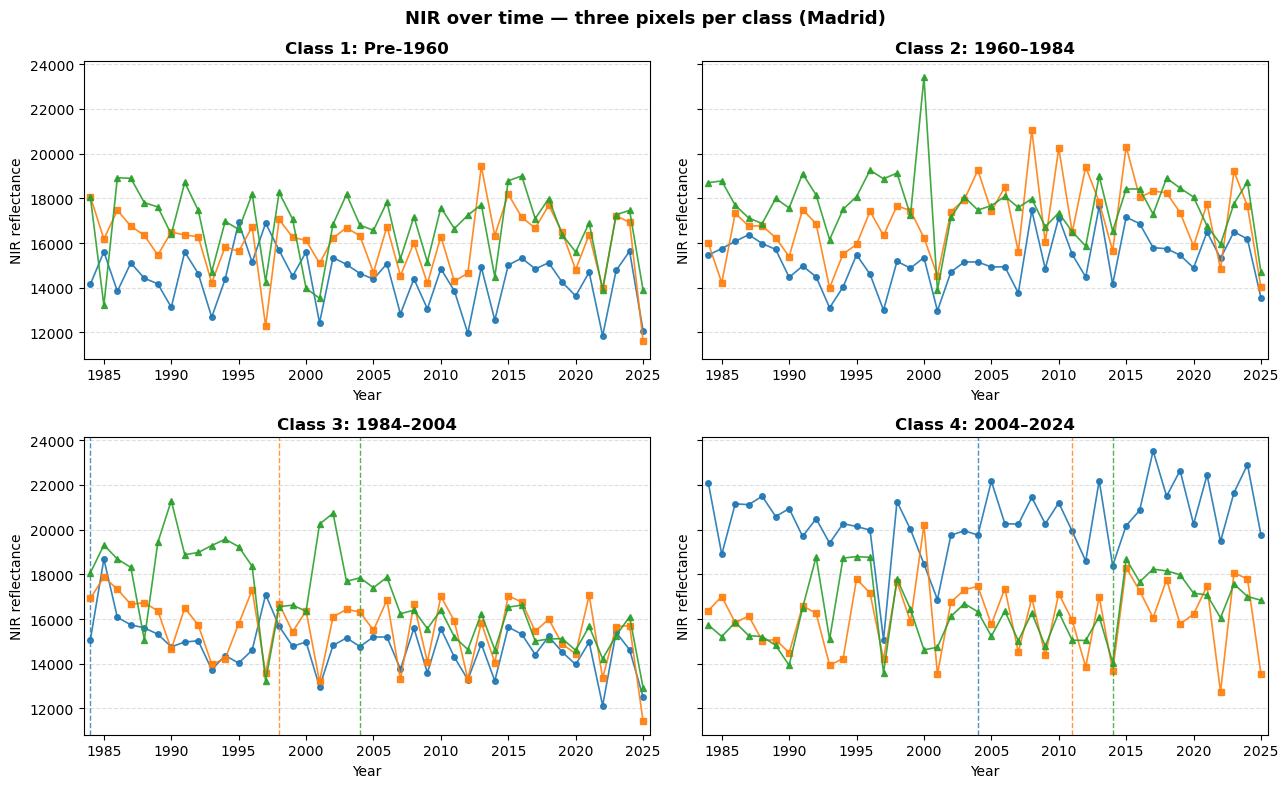

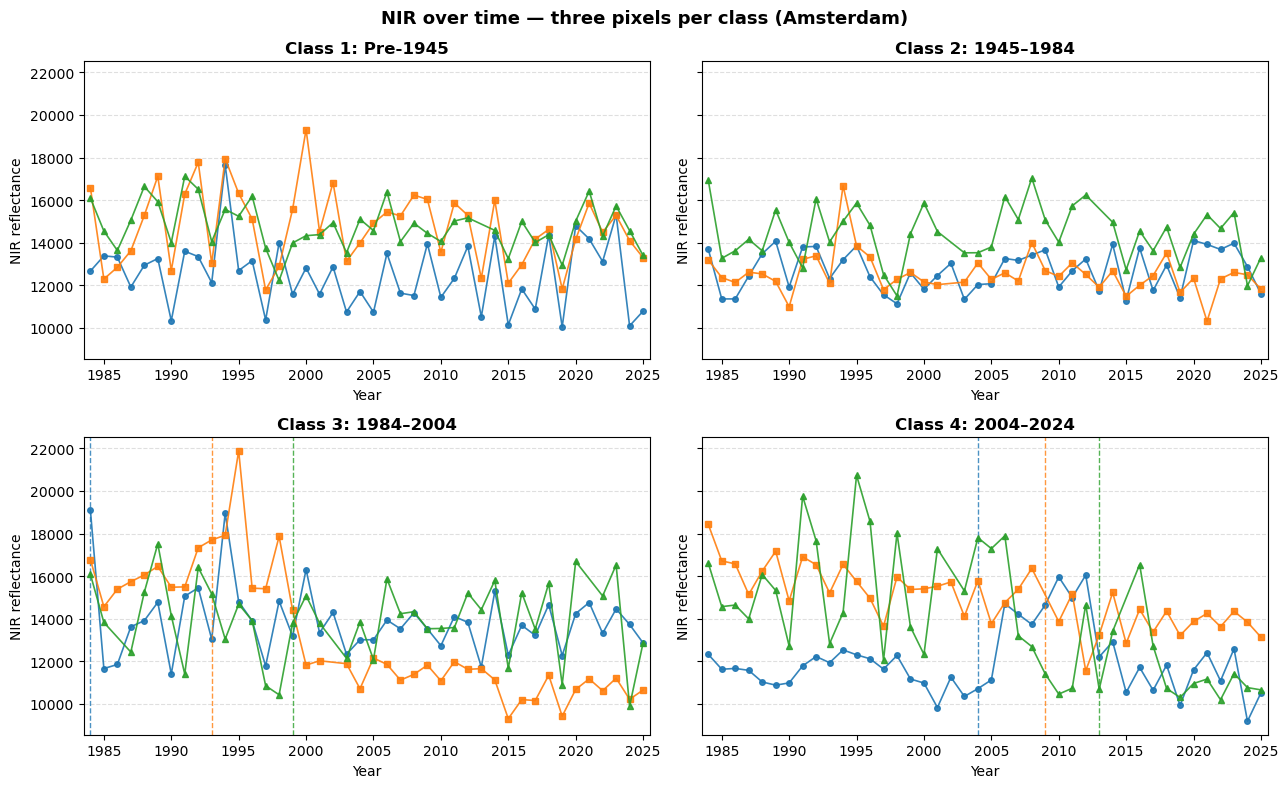

In [14]:
for city_name, flat, _ in CITIES:
    plot_pixel_ts('NIR', flat, class_pixels[city_name])


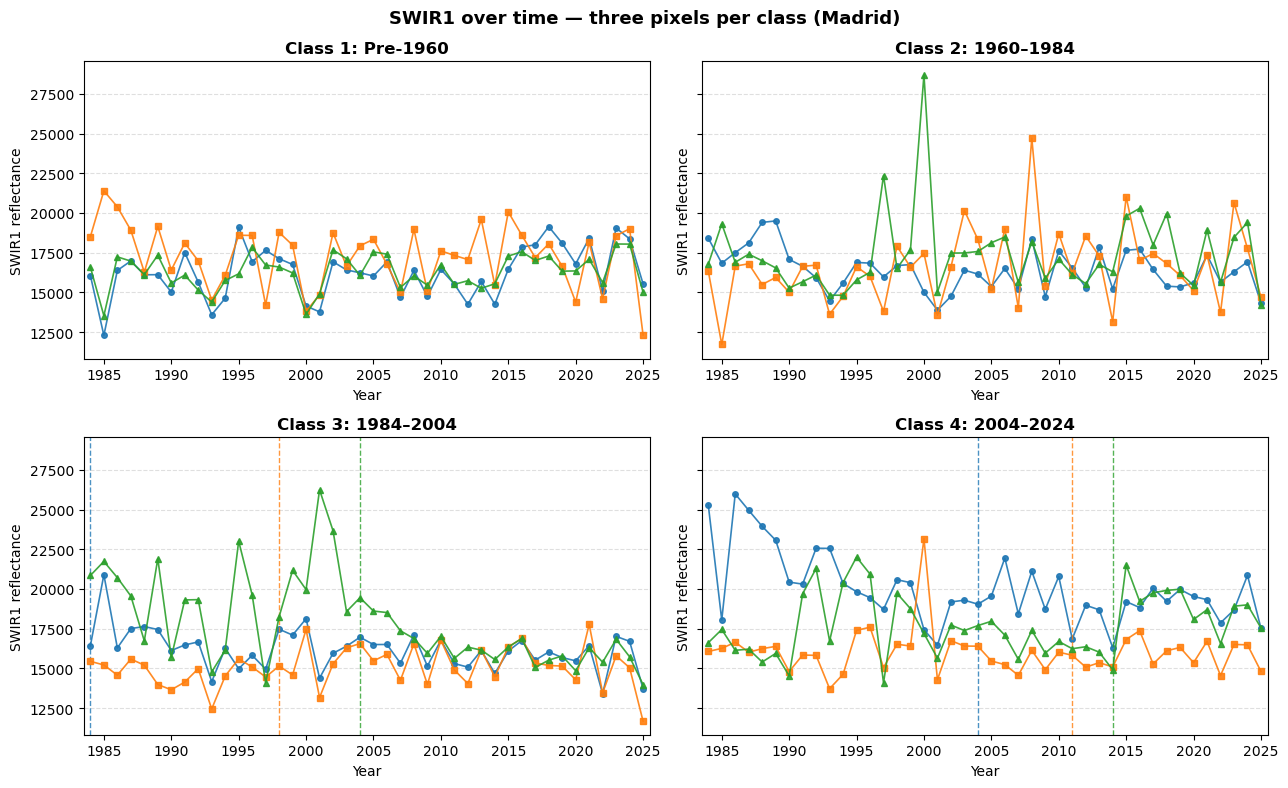

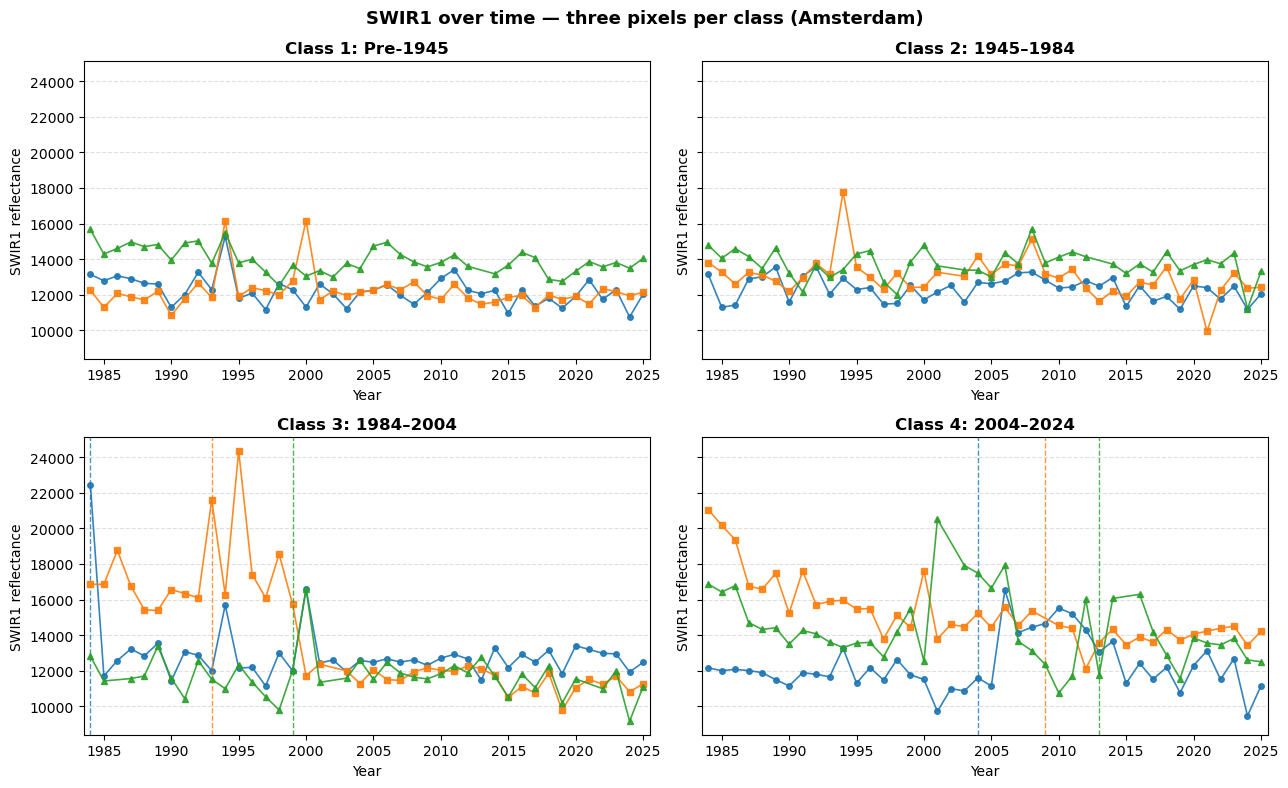

In [15]:
for city_name, flat, _ in CITIES:
    plot_pixel_ts('SWIR1', flat, class_pixels[city_name])


The individual-pixel time series do not show a strong visible difference in reflectance level among age classes. However, two patterns are worth noting:

- **Decreasing trend:** Most pixels show a gradual decline in reflectance over the full observation period, likely reflecting long-term changes in urban surface properties (weathering, grime accumulation, urban greening).
- **Construction-year effects (Classes 3 and 4):** There is a possible interruption or shift in this trend near the construction year (marked by the dashed vertical line), and possibly increased variance in reflectance around that date. This is physically plausible — active construction sites have very different spectral properties from finished buildings — and may be a useful feature for the model.

---

## 2.7 Time Series: Class-Level Yearly Trends

The single-pixel plots above show individual trajectories that are inherently noisy.
To reveal broader patterns, the plots below show the **mean reflectance across all
pixels in each class, computed for each year separately**, with ±1 standard deviation
shading.

The shaded region shows pixel-to-pixel spread within a class (how variable the class
is at a given year), not measurement uncertainty. A wide shaded band means the class
contains surfaces with diverse reflectance values.


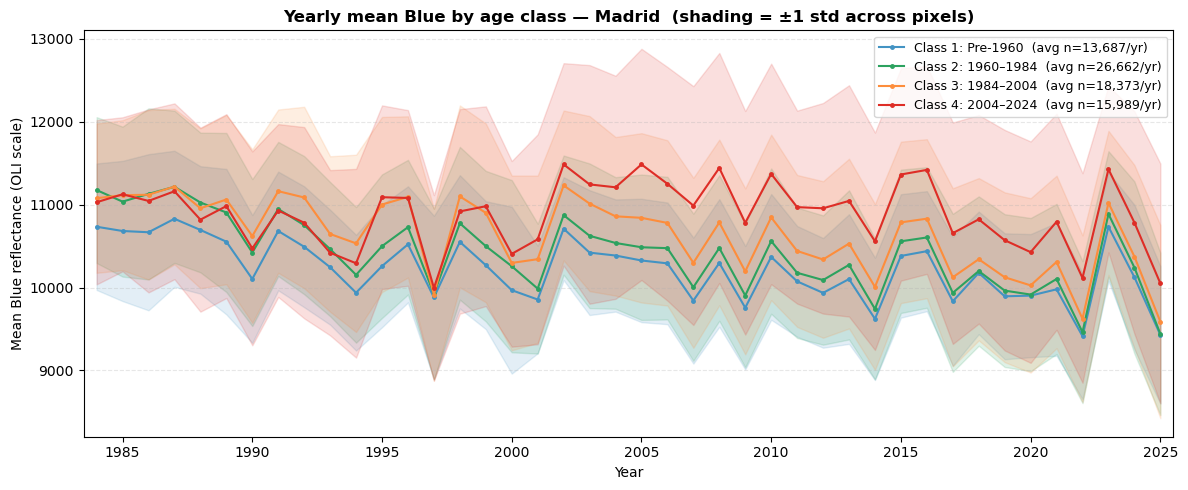

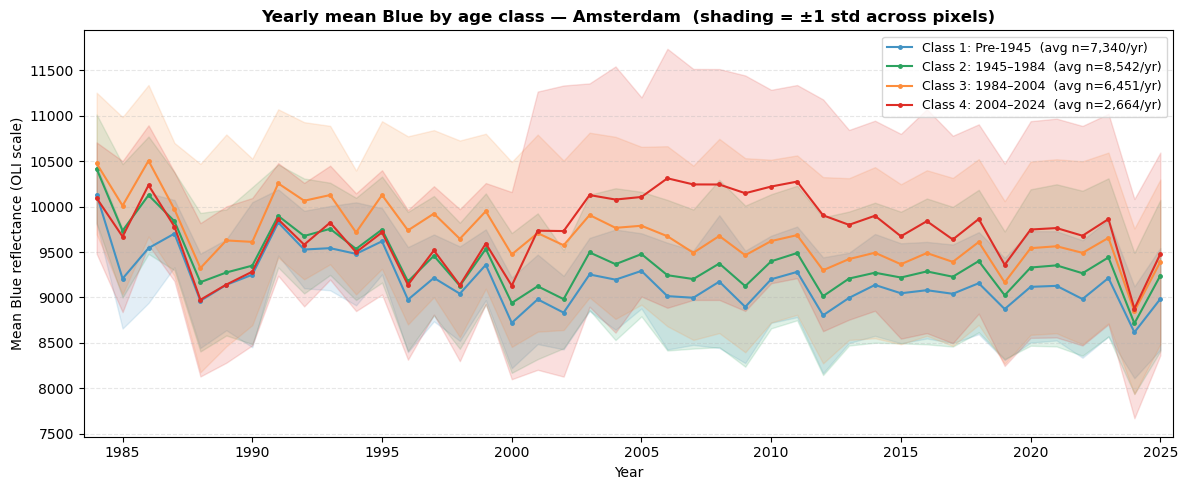

In [16]:
def get_yearly_means(data, band):
    tmp = data[['year', 'age_class', band]].dropna()
    return tmp.groupby(['year', 'age_class'])[band].agg(['mean', 'std', 'count']).reset_index()

def plot_yearly_class_means(band, data):
    city   = data['city'].iloc[0]
    labels = CLASS_LABELS.get(city, CLASS_LABELS['Madrid'])
    stats  = get_yearly_means(data, band)
    fig, ax = plt.subplots(figsize=(12, 5))
    for cls in sorted(stats['age_class'].dropna().unique()):
        cls   = int(cls)
        sub   = stats[stats['age_class'] == cls].sort_values('year')
        color = CLASS_COLORS.get(cls, 'grey')
        lbl   = labels.get(cls, f'Class {cls}')
        avg_n = int(sub['count'].mean())
        ax.plot(sub['year'], sub['mean'], color=color, marker='.', markersize=5,
                linewidth=1.5, label=f'Class {cls}: {lbl}  (avg n={avg_n:,}/yr)')
        ax.fill_between(sub['year'],
                        sub['mean'] - sub['std'], sub['mean'] + sub['std'],
                        color=color, alpha=0.15)
    ax.set_xlim(YEAR_MIN - 0.5, YEAR_MAX + 0.5)
    ax.set_xlabel('Year')
    ax.set_ylabel(f'Mean {band} reflectance (OLI scale)')
    ax.set_title(f'Yearly mean {band} by age class — {city}  (shading = ±1 std across pixels)',
                 fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout(); plt.show()

for city_name, flat, _ in CITIES:
    plot_yearly_class_means('Blue', flat)


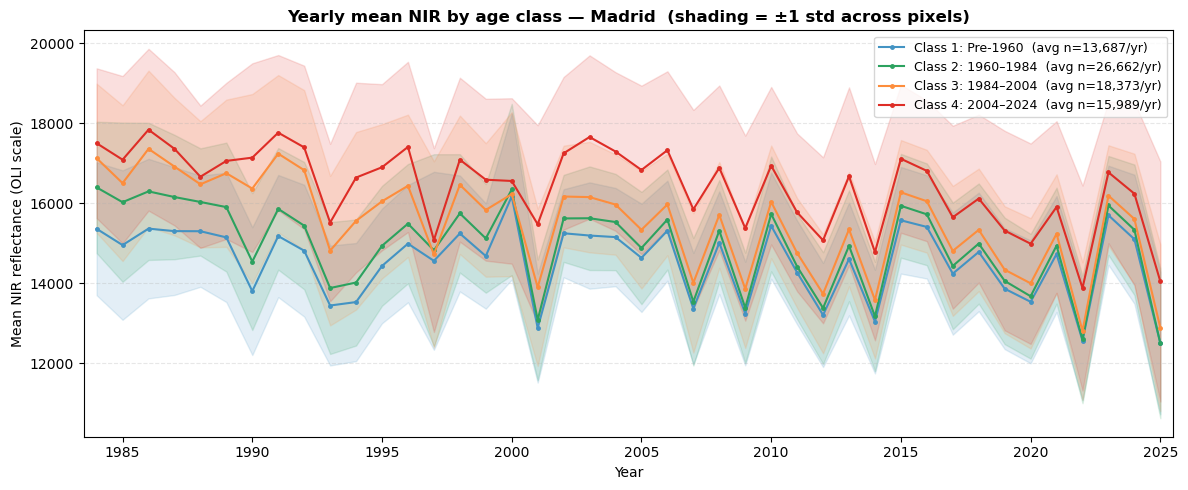

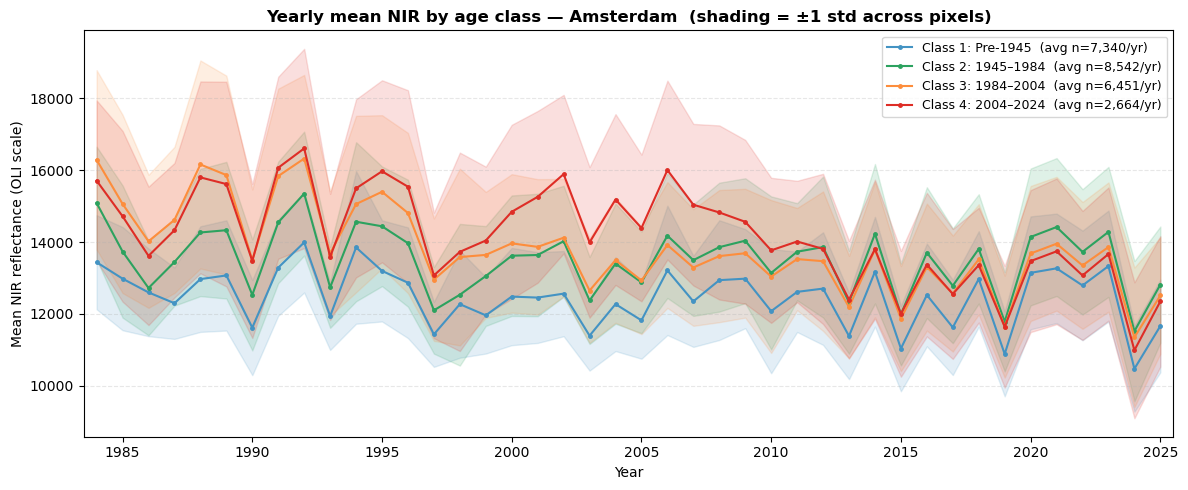

In [17]:
for city_name, flat, _ in CITIES:
    plot_yearly_class_means('NIR', flat)


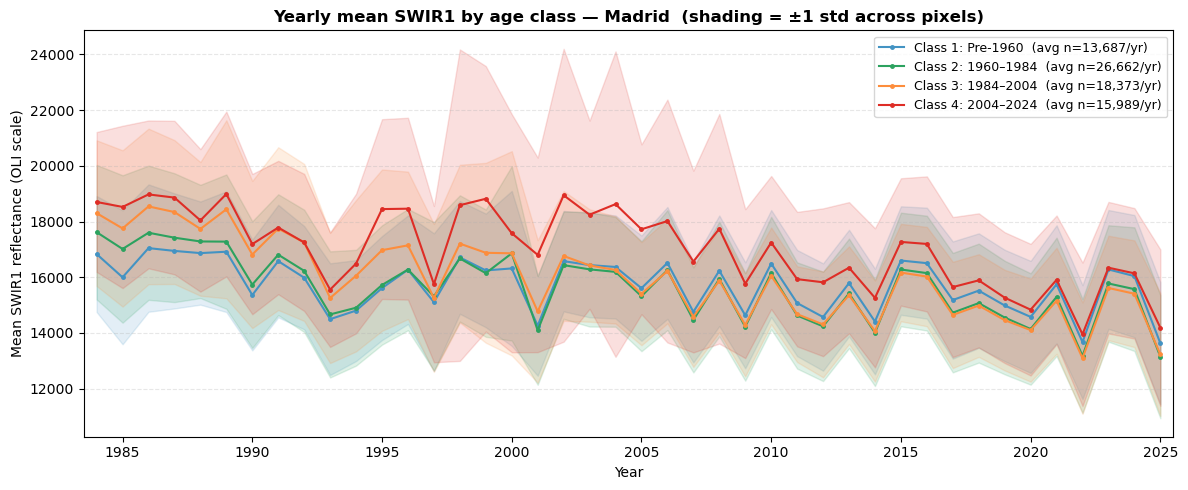

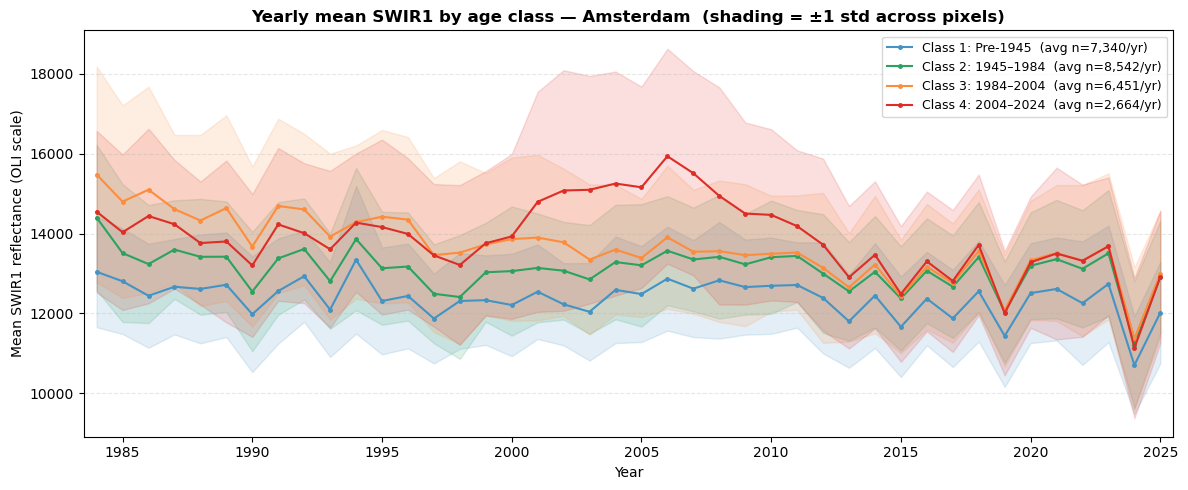

In [18]:
for city_name, flat, _ in CITIES:
    plot_yearly_class_means('SWIR1', flat)


A notable pattern in the class-level yearly trend plots is the **time-varying variability of Class 4** (built 2004–2024). The shaded band (±1 std across pixels) for Class 4 is substantially wider than for the other classes during certain periods:

- **Blue band:** Class 4 variance increases markedly around the year 2000 and remains elevated well above the other classes for a sustained period.
- **SWIR1 band:** Class 4 shows high cross-pixel variance roughly between 2000 and 2015, after which it subsides and converges toward the other classes.

This is physically plausible: pixels classified as Class 4 (construction date 2004–2024) were in various stages of development during the 2000–2015 window — some were bare ground or active construction sites, others already completed buildings. This heterogeneity in surface state drives high variance across the class. Once construction was largely complete post-2015, the pixels converge to a more uniform finished-building signature.

This temporal variance pattern could itself be a useful feature: a pixel that shows anomalously high cross-year variance in Blue or SWIR1 around 2000–2015 is more likely to belong to Class 4.

---

## Pixel-Level Temporal Distributions

For each geographic pixel we compute statistics across its full annual time series:
- **Mean** and **standard deviation** of annual reflectance values
- **Mean** and **standard deviation** of year-on-year differences (value in year *n* minus value in year *n*−1)

Histograms show all four age classes simultaneously (dodged bars), for every spectral band.

In [19]:
def compute_pixel_stats(flat):
    """Per-pixel temporal mean/std and year-on-year diff mean/std for all bands."""
    s = flat[flat['age_class'].notna()].copy()
    s = s.sort_values(['px_key', 'py_key', 'year'])

    grp  = s.groupby(['px_key', 'py_key', 'age_class'])[BASE_BANDS]
    base = pd.concat([grp.mean().add_suffix('_mean'),
                      grp.std().add_suffix('_std')], axis=1).reset_index()
    base['age_class'] = base['age_class'].astype(int)

    for b in BASE_BANDS:
        s[f'd_{b}'] = s.groupby(['px_key', 'py_key'])[b].diff()
    dcols    = [f'd_{b}' for b in BASE_BANDS]
    dgrp     = s.groupby(['px_key', 'py_key'])[dcols]
    diff_base = pd.concat([dgrp.mean().add_suffix('_mean'),
                           dgrp.std().add_suffix('_std')], axis=1).reset_index()

    return base.merge(diff_base, on=['px_key', 'py_key'])

pixel_stats = {}
for city_name, flat, _ in CITIES:
    pixel_stats[city_name] = compute_pixel_stats(flat)
    print(f"{city_name}: {len(pixel_stats[city_name]):,} pixels")


Madrid: 76,263 pixels
Amsterdam: 25,992 pixels


In [20]:
def plot_dodged_hist(ax, ps, col, n_bins=40):
    classes = sorted(ps['age_class'].dropna().unique().astype(int))
    all_v   = ps[col].dropna().values
    if len(all_v) == 0:
        return
    lo, hi  = np.percentile(all_v, [1, 99])
    bins    = np.linspace(lo, hi, n_bins + 1)
    bw      = bins[1] - bins[0]
    bar_w   = bw / len(classes) * 0.88
    for i, cls in enumerate(classes):
        vals = ps.loc[ps['age_class'] == cls, col].dropna().values
        counts, _ = np.histogram(vals, bins=bins)
        counts = counts / max(counts.sum(), 1)
        offset = (i - (len(classes) - 1) / 2) * bar_w
        ax.bar(bins[:-1] + bw / 2 + offset, counts, width=bar_w,
               color=CLASS_COLORS.get(cls, 'grey'), alpha=0.85,
               label=f'Class {cls}')
    ax.tick_params(labelsize=7)

def plot_metric_grid(col_fmt, suptitle, xlabel):
    fig, axes = plt.subplots(2, len(BASE_BANDS), figsize=(20, 7), sharey='row')
    for row, (city_name, flat, _) in enumerate(CITIES):
        ps = pixel_stats[city_name]
        for ci, band in enumerate(BASE_BANDS):
            ax = axes[row, ci]
            plot_dodged_hist(ax, ps, col_fmt.format(band=band))
            if row == 0:
                ax.set_title(band, fontweight='bold', fontsize=10)
            if ci == 0:
                ax.set_ylabel(f'{city_name}\nFraction', fontsize=9)
            if row == 1:
                ax.set_xlabel(xlabel, fontsize=8)
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


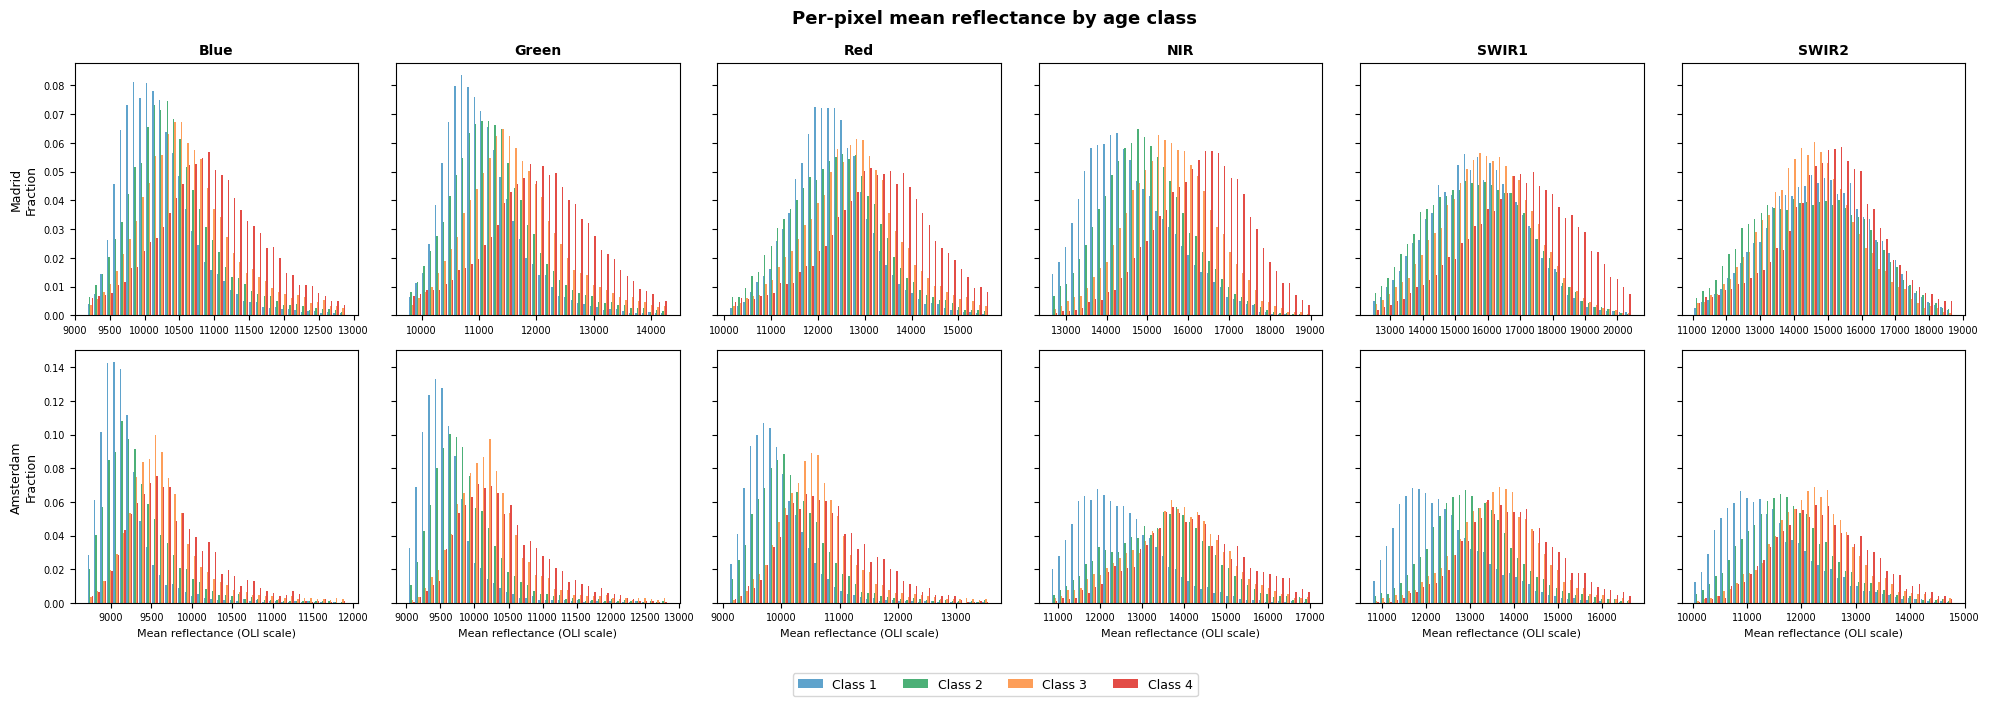

In [21]:
plot_metric_grid('{band}_mean',
                 'Per-pixel mean reflectance by age class',
                 'Mean reflectance (OLI scale)')


**Per-pixel mean reflectance:** Distribution means are visibly different between classes — Class 1 has the lowest mean and Class 4 the highest. The Class 1 distribution is strongly peaked in the visible bands (Blue, Green, Red), while Class 4 distributions are most spread out. This is promising: it shows there is a discernible spectral difference between age classes that a model can exploit.

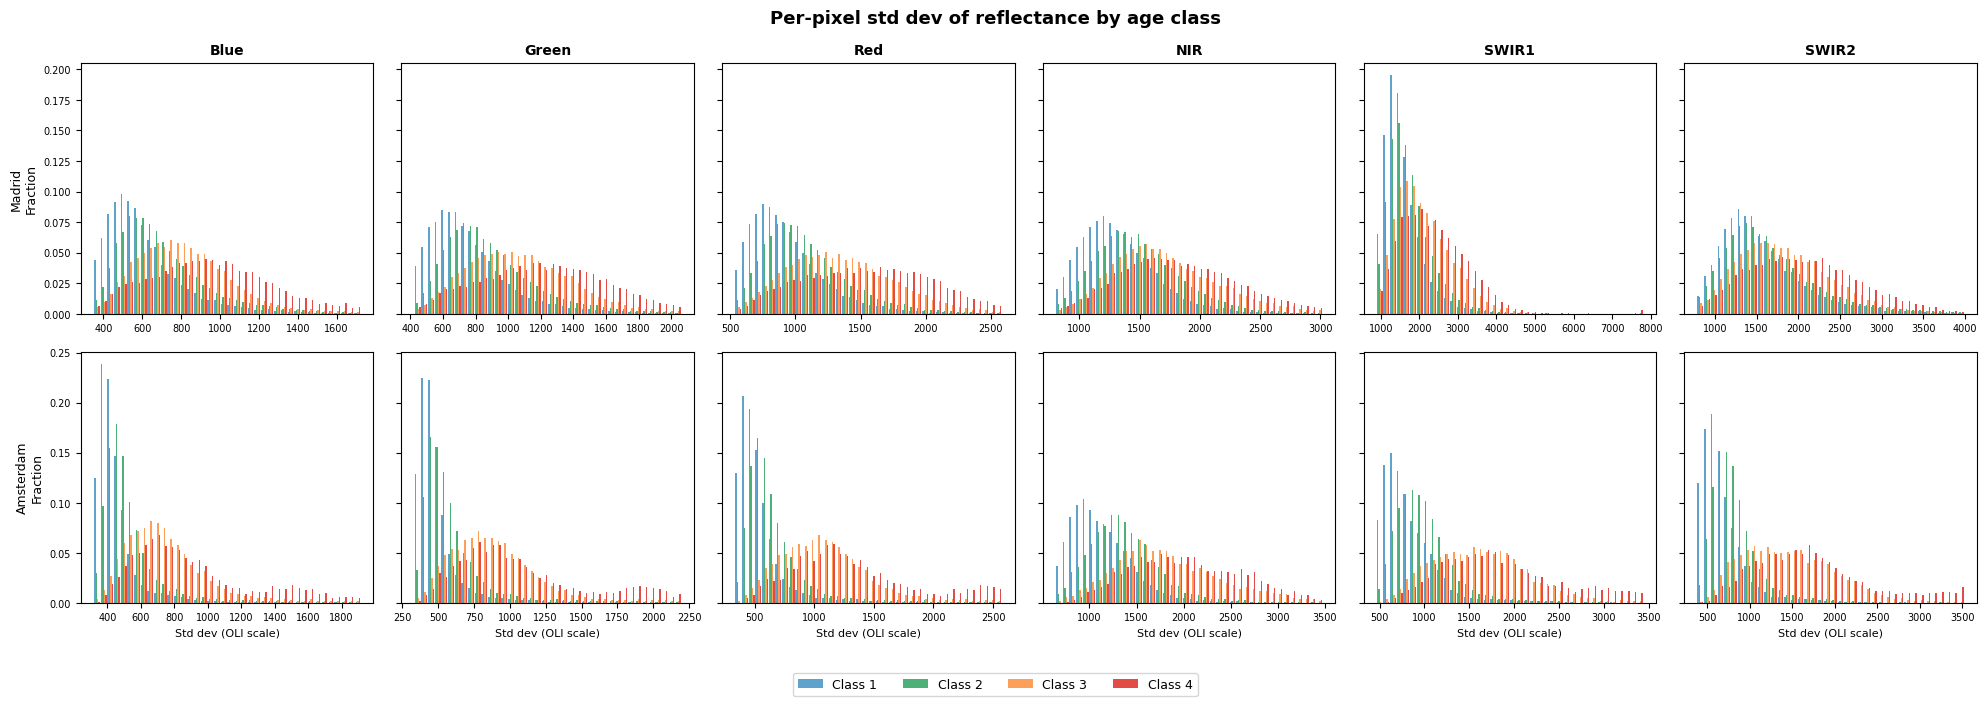

In [22]:
plot_metric_grid('{band}_std',
                 'Per-pixel std dev of reflectance by age class',
                 'Std dev (OLI scale)')


**Per-pixel std dev of reflectance:** Distributions show similar characteristics to the means — the same class ordering and shape patterns are visible, suggesting that pixels with higher mean reflectance also tend to show greater year-to-year variability.

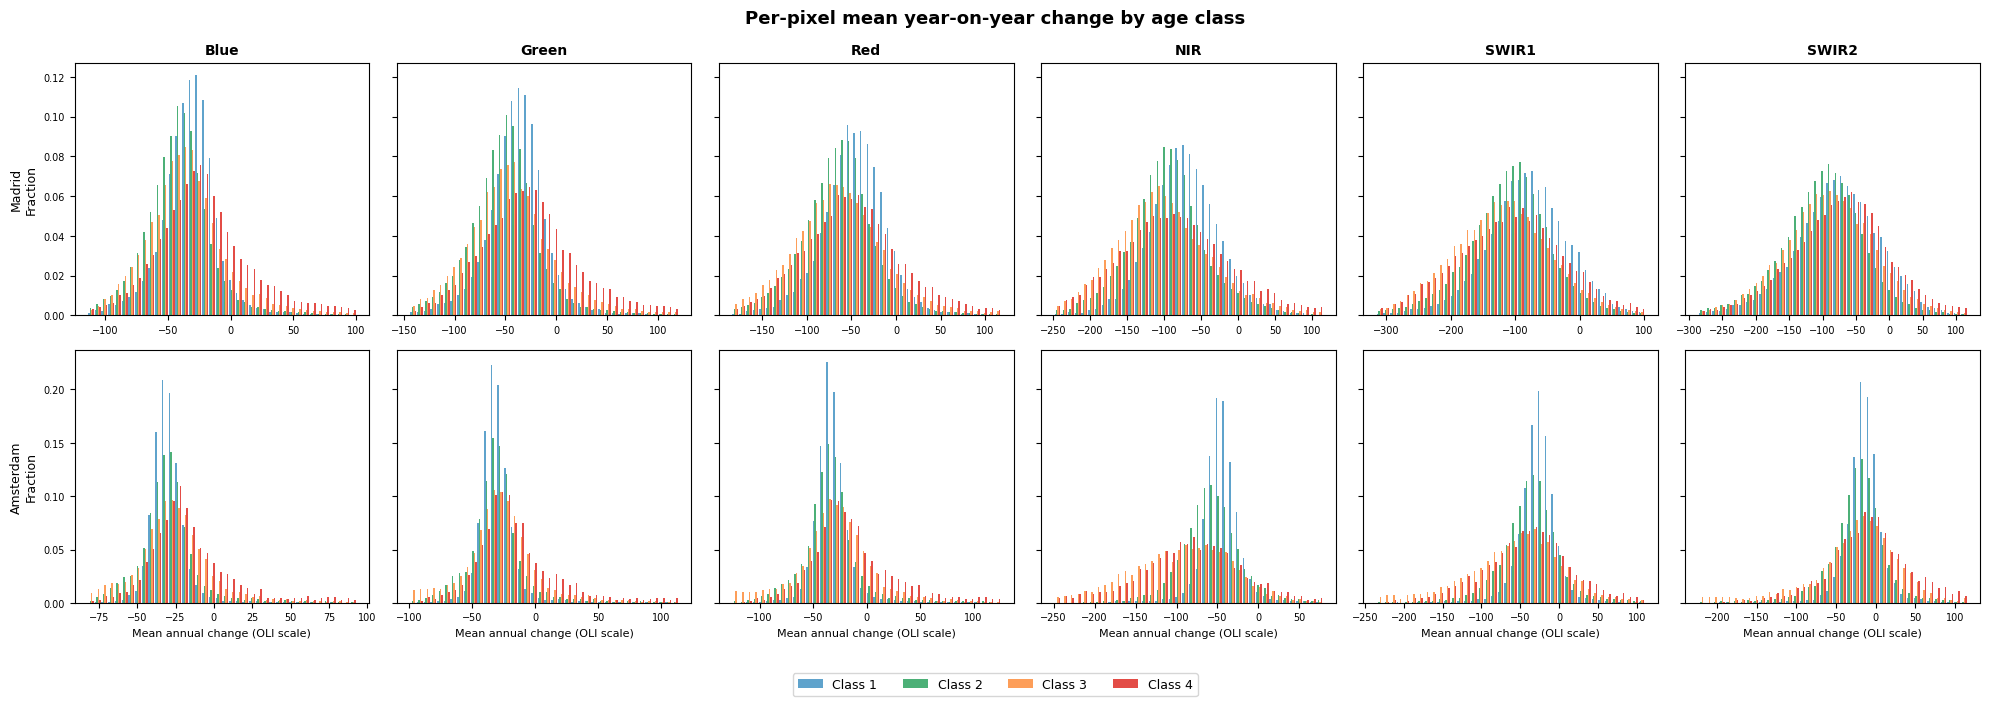

In [23]:
plot_metric_grid('d_{band}_mean',
                 'Per-pixel mean year-on-year change by age class',
                 'Mean annual change (OLI scale)')


**Per-pixel mean year-on-year change:** Distribution means are similar across classes — all centred near zero, indicating no systematic long-term trend for most pixels. Class 4 is the most spread out and Class 1 the most strongly peaked, meaning older buildings show more stable year-on-year reflectance while newer buildings exhibit larger swings.

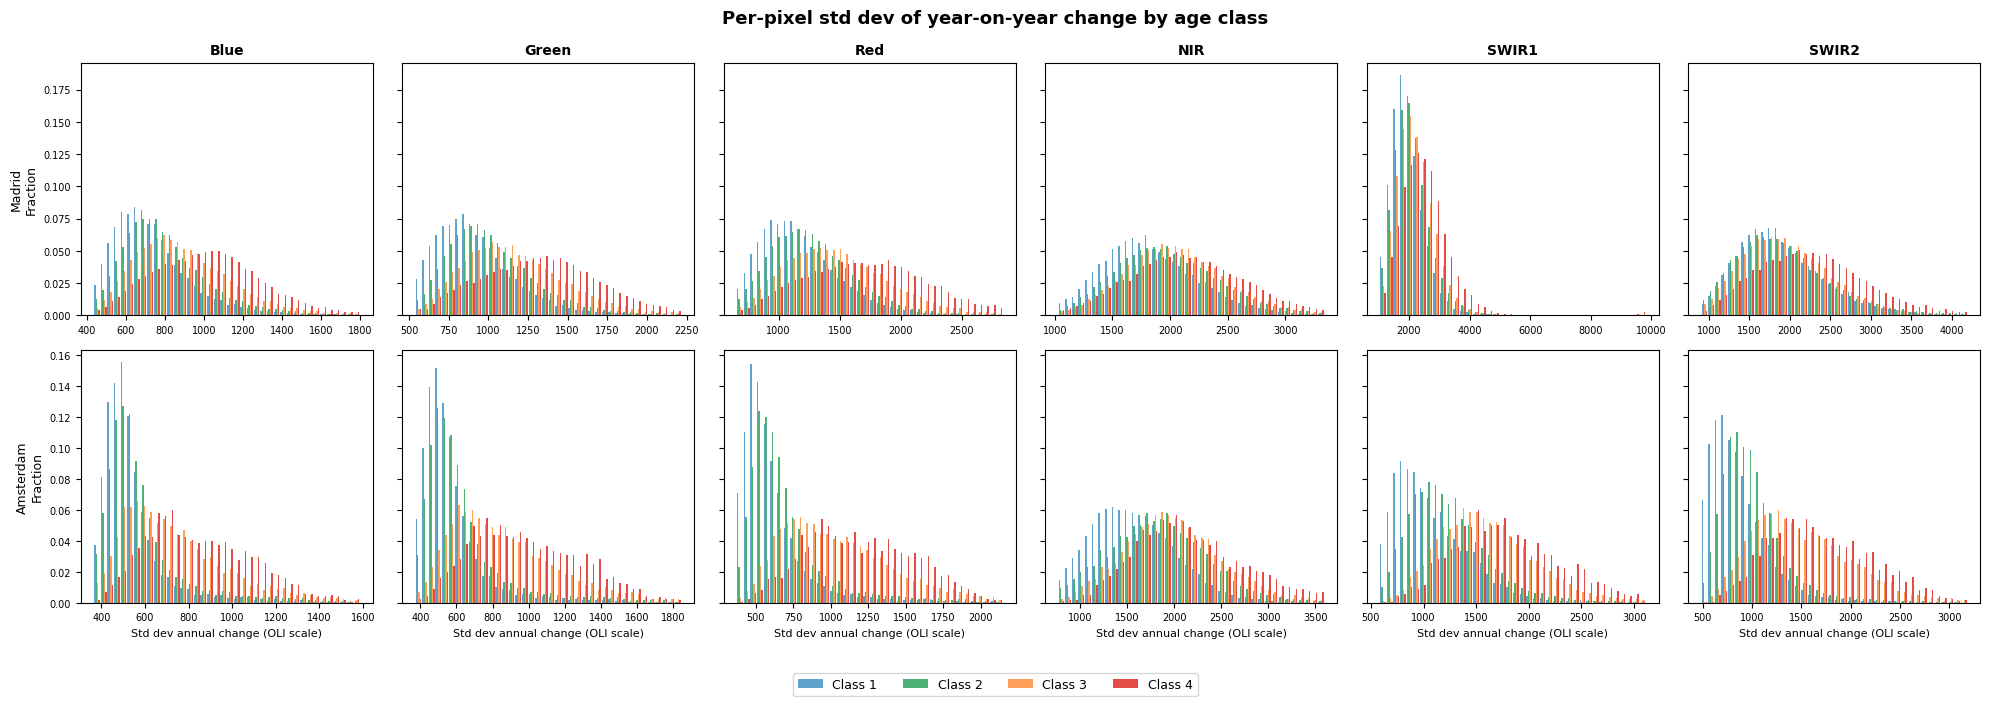

In [24]:
plot_metric_grid('d_{band}_std',
                 'Per-pixel std dev of year-on-year change by age class',
                 'Std dev annual change (OLI scale)')


**Per-pixel std dev of year-on-year change:** Classes 1 and 2 have similar, narrow distributions (low variability in annual change), while Classes 3 and 4 have similar, broader distributions. This split at the 1984 boundary — the start of the Landsat record — makes sense: buildings that predate the satellite era have a stable, settled spectral signature, whereas buildings constructed during the observation period may show transient reflectance changes around the time of construction.

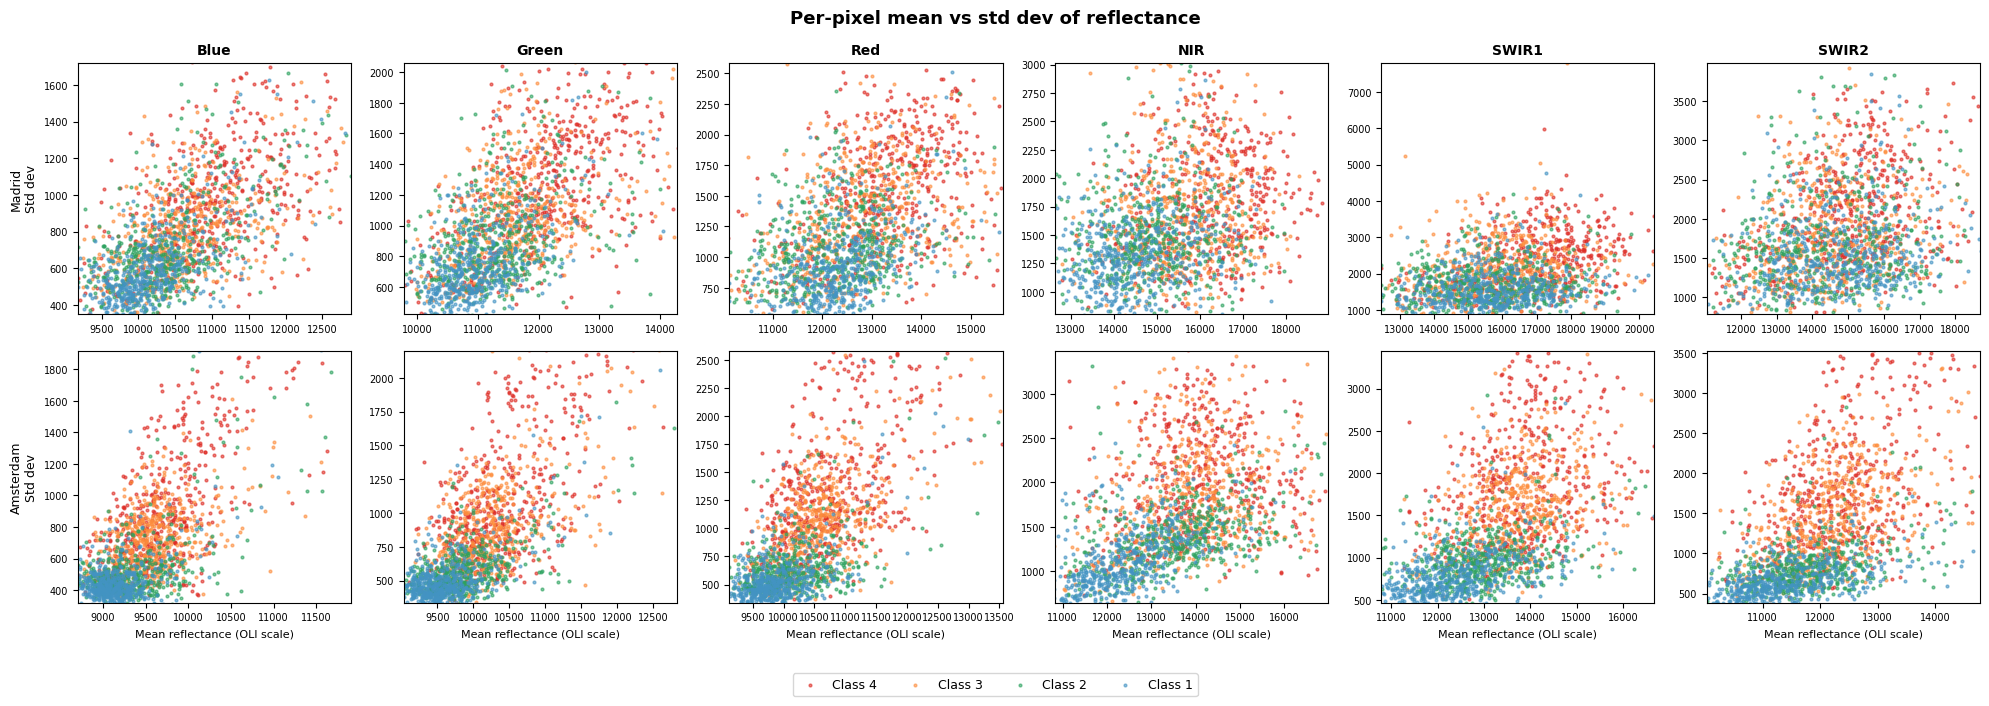

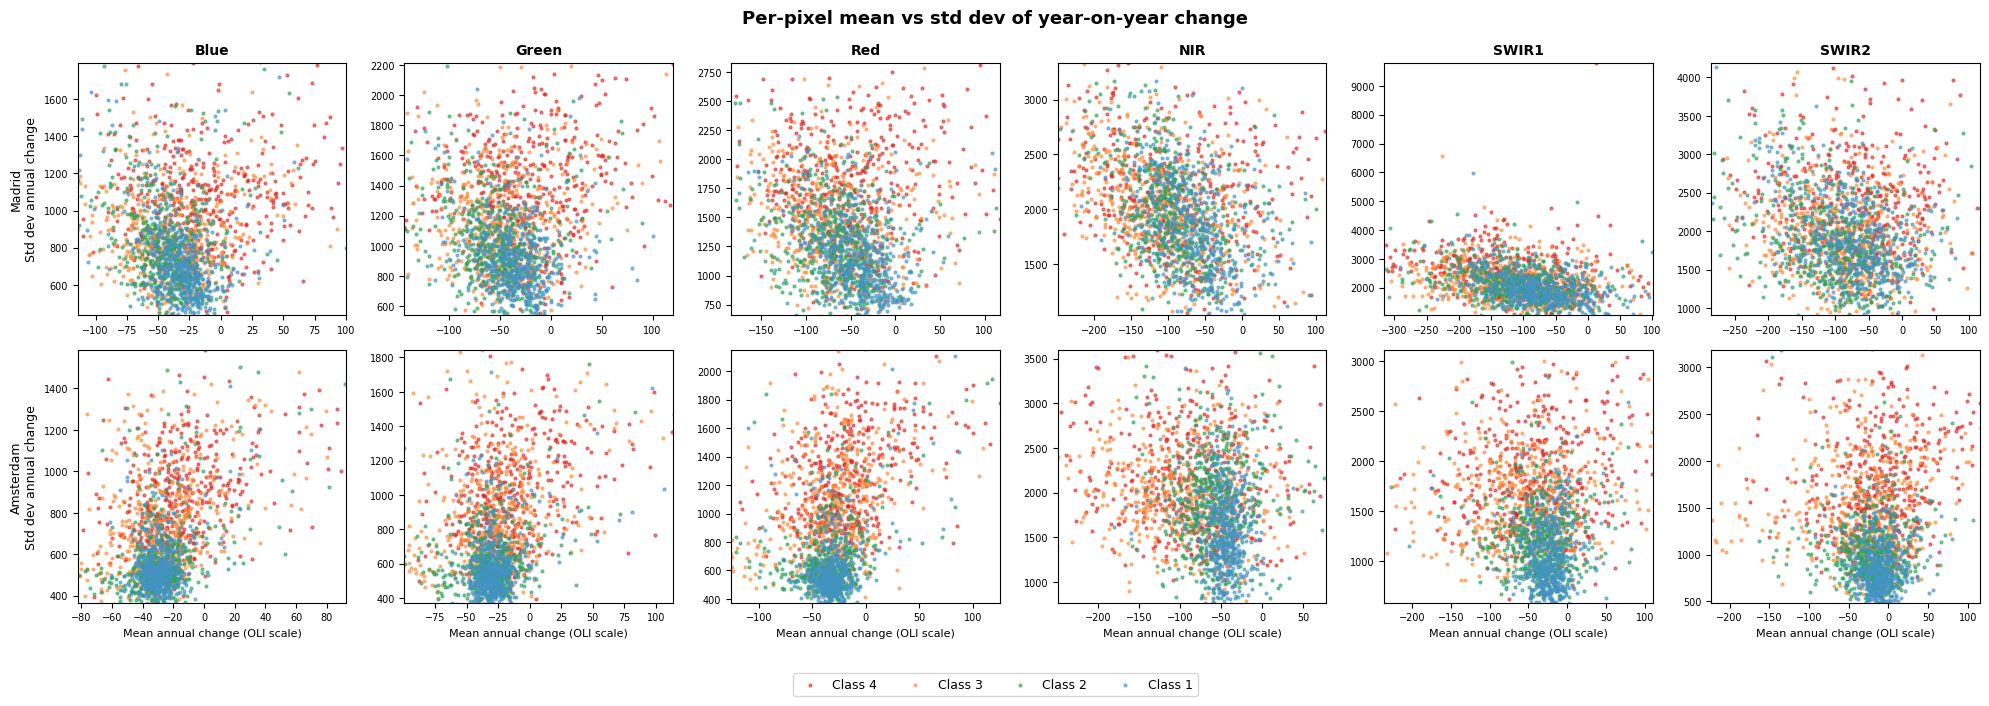

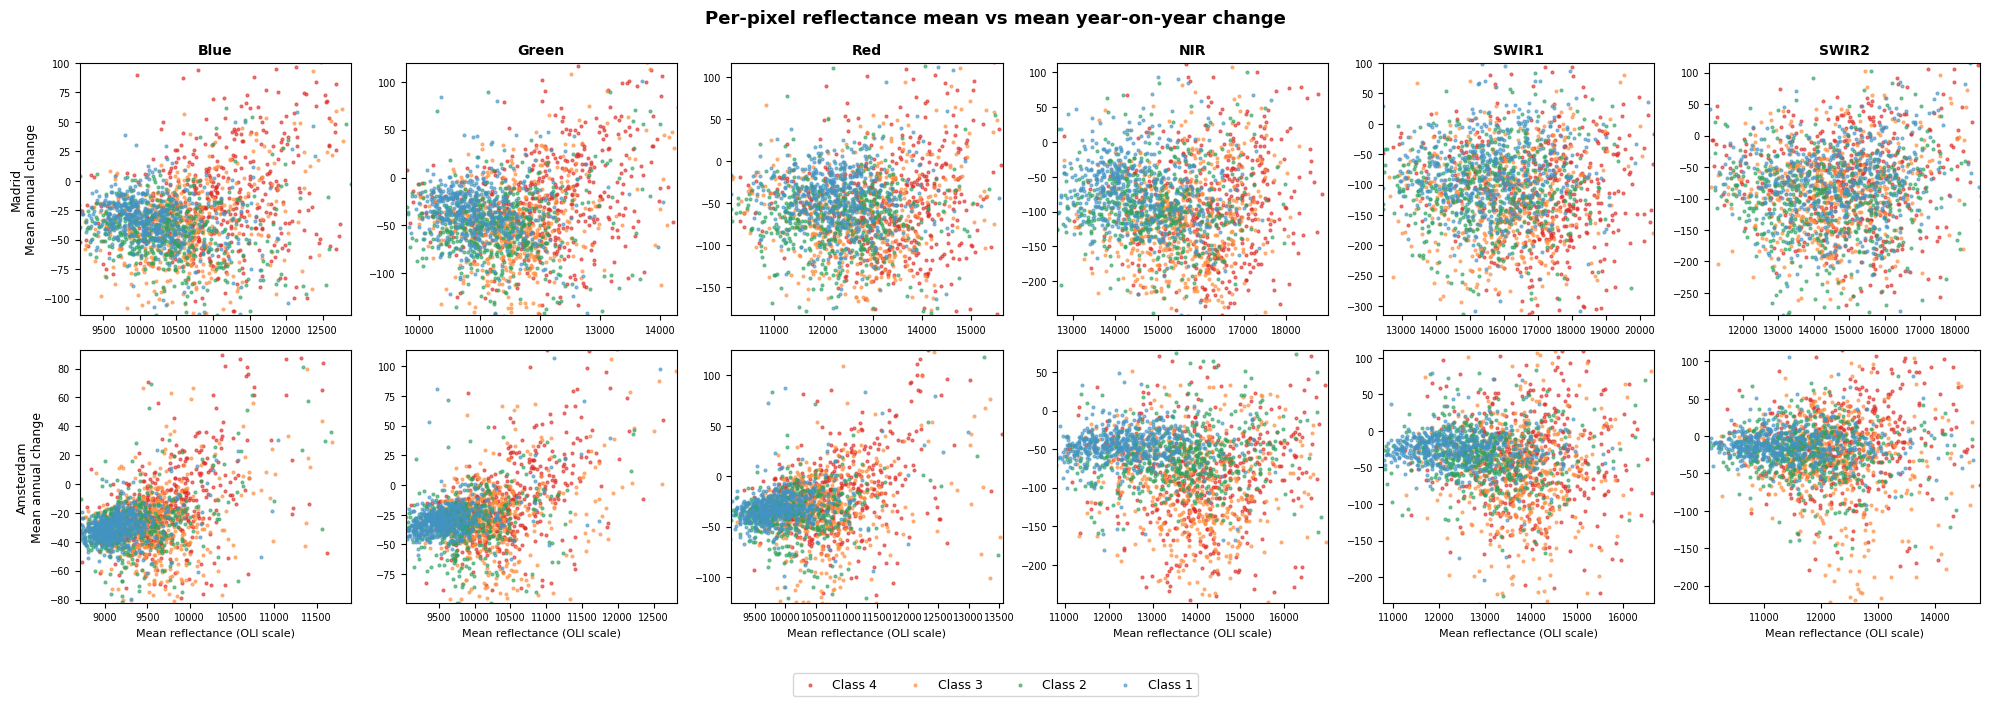

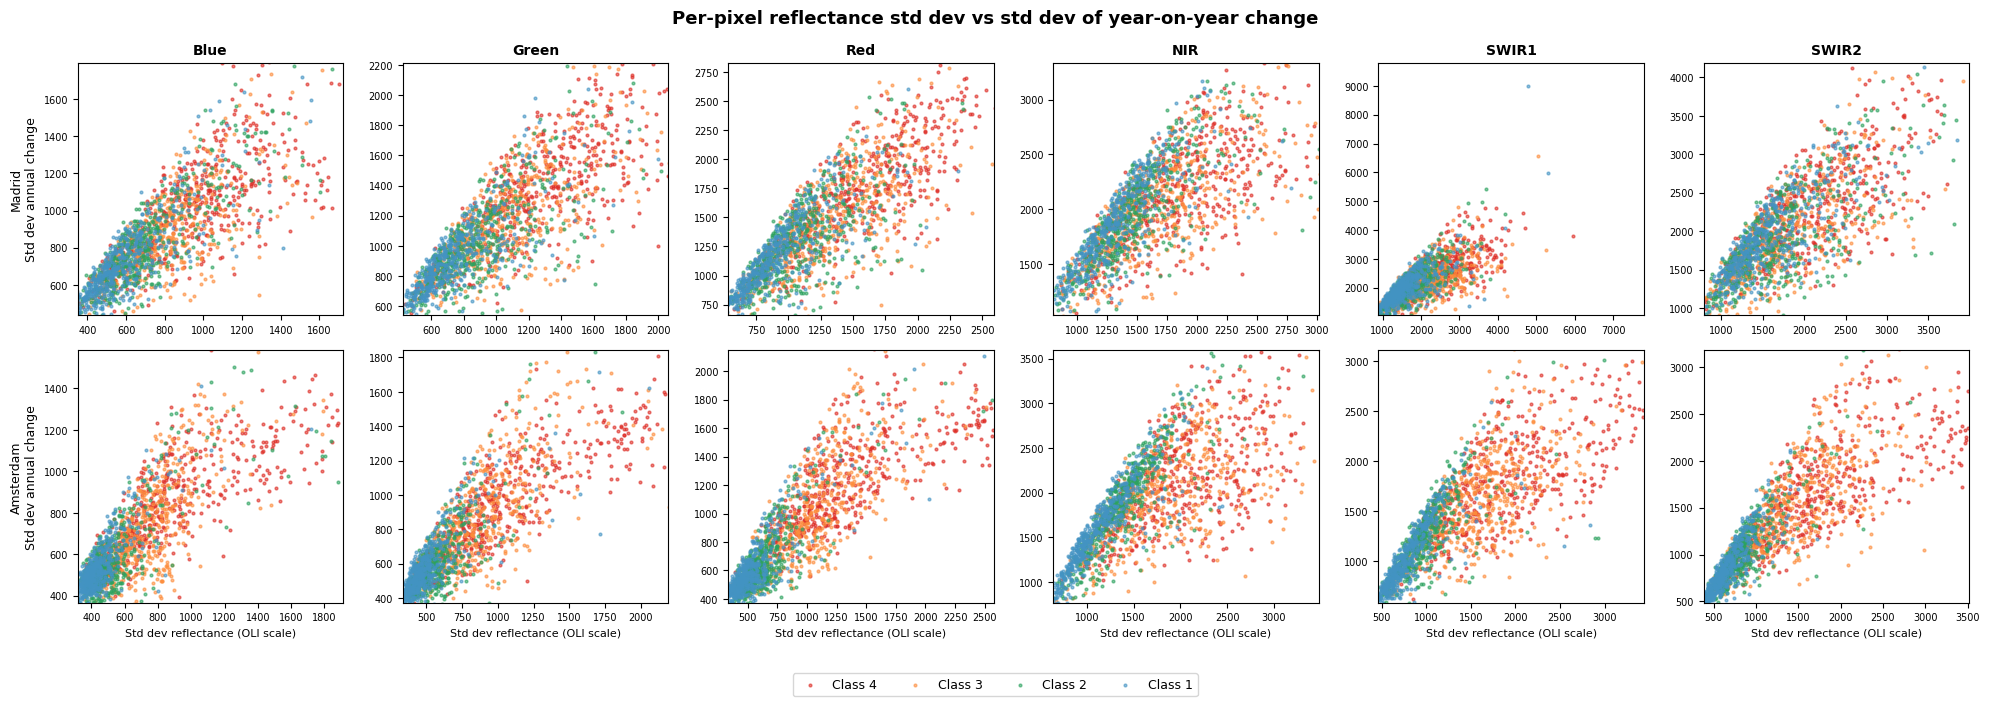

In [25]:
def plot_scatter_grid(xcol_fmt, ycol_fmt, suptitle, xlabel, ylabel, n_sample=500):
    fig, axes = plt.subplots(2, len(BASE_BANDS), figsize=(20, 7))
    rng = np.random.default_rng(42)
    for row, (city_name, flat, _) in enumerate(CITIES):
        ps = pixel_stats[city_name]
        for ci, band in enumerate(BASE_BANDS):
            ax   = axes[row, ci]
            xcol = xcol_fmt.format(band=band)
            ycol = ycol_fmt.format(band=band)
            xl   = np.percentile(ps[xcol].dropna(), [1, 99])
            yl   = np.percentile(ps[ycol].dropna(), [1, 99])
            for cls in [4, 3, 2, 1]:
                sub = ps[ps["age_class"] == cls][[xcol, ycol]].dropna()
                if len(sub) > n_sample:
                    idx = rng.choice(len(sub), n_sample, replace=False)
                    sub = sub.iloc[idx]
                lbl = f"Class {cls}" if (row == 0 and ci == 0) else ""
                ax.scatter(sub[xcol], sub[ycol],
                           color=CLASS_COLORS.get(cls, "grey"),
                           s=4, alpha=0.6, label=lbl)
            ax.set_xlim(xl); ax.set_ylim(yl)
            if row == 0:
                ax.set_title(band, fontweight="bold", fontsize=10)
            if ci == 0:
                ax.set_ylabel(city_name + "\n" + ylabel, fontsize=9)
            if row == 1:
                ax.set_xlabel(xlabel, fontsize=8)
            ax.tick_params(labelsize=7)
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc="lower center", ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

plot_scatter_grid("{band}_mean",   "{band}_std",
                  "Per-pixel mean vs std dev of reflectance",
                  "Mean reflectance (OLI scale)", "Std dev")
plot_scatter_grid("d_{band}_mean", "d_{band}_std",
                  "Per-pixel mean vs std dev of year-on-year change",
                  "Mean annual change (OLI scale)", "Std dev annual change")
plot_scatter_grid("{band}_mean",   "d_{band}_mean",
                  "Per-pixel reflectance mean vs mean year-on-year change",
                  "Mean reflectance (OLI scale)", "Mean annual change")
plot_scatter_grid("{band}_std",    "d_{band}_std",
                  "Per-pixel reflectance std dev vs std dev of year-on-year change",
                  "Std dev reflectance (OLI scale)", "Std dev annual change")


---

## 2.8 Feature Exploration

#### Band statistics


In [26]:
df_flat[BASE_BANDS].describe().round(1)


,Blue,Green,Red,NIR,SWIR1,SWIR2
count,3137920.0,3137920.0,3137920.0,3137920.0,3137920.0,3137920.0
mean,10532.4,11473.5,12618.9,15324.3,16036.4,14649.2
std,1089.6,1378.5,1710.2,2121.8,2780.6,2496.6
min,0.0,0.0,501.0,6834.0,6987.5,7292.8
25%,9791.9,10537.0,11458.9,13904.8,14196.7,12857.8
50%,10378.0,11266.0,12458.1,15241.5,15817.9,14441.1
75%,11089.3,12183.2,13577.2,16602.3,17578.5,16211.3
max,15000.0,38274.0,64388.1,66013.4,66655.6,66177.2


#### Data quality check

The pipeline pre-cleaned the data. Let's verify no corrupt pixels remain in `df_flat`.


In [27]:
for city_name, flat, _ in CITIES:
    is_zero      = (flat[BASE_BANDS] == 0).any(axis=1)
    is_saturated = (flat[BASE_BANDS] == 65535).any(axis=1)
    n_corrupt    = (is_zero | is_saturated).sum()
    status = "clean" if n_corrupt == 0 else f"WARNING — {n_corrupt:,} corrupt rows"
    print(f"{city_name:12s}: {len(flat):,} rows — {status}")


Madrid      : 3,137,920 rows — WARNING — 23 corrupt rows
Amsterdam   : 1,049,960 rows — WARNING — 7 corrupt rows


#### Correlation between bands

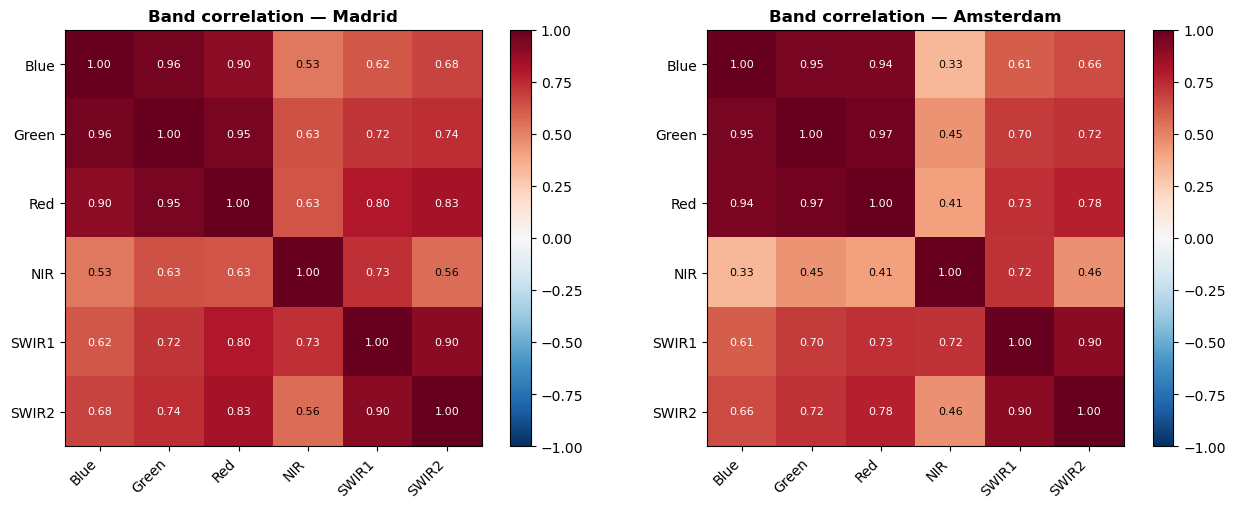

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
n = len(BASE_BANDS)
for ax, (city_name, flat, _) in zip(axes, CITIES):
    corr = flat[BASE_BANDS].corr().values
    im   = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(BASE_BANDS, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(BASE_BANDS)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(corr[i,j]) > 0.6 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Band correlation — {city_name}', fontweight='bold')
plt.tight_layout(); plt.show()


The visible bands (Blue, Green, Red) are highly correlated with each other, indicating substantial redundancy within RGB. NIR, SWIR1, and SWIR2 are less strongly correlated with the visible bands, suggesting they provide additional spectral information beyond RGB. This supports the expectation that multispectral data may be more informative than RGB alone for this task.

---

## 2.11 Summary

Key takeaways from this notebook:

- The dataset is in **wide format**: each row is one geographic pixel in one year,
  with up to 3 observations per row. `df_flat` / `df_ams_flat` extract the best
  valid observation per row for feature analysis.
- **Age classes** are derived from `weighted_mean_year` using city-specific construction
  event boundaries (Madrid: 1960, Amsterdam: 1945) plus fixed 20-year satellite-era
  boundaries (1984–2004, 2004–2024).
- **Class 1 dominates** in both cities — class imbalance must be addressed in preprocessing.

### What the plots suggest about useful features

**Mean reflectance level** (per-pixel mean across years) is the most immediately
promising feature: Class 1 has the lowest mean and Class 4 the highest across all
bands, with Class 1 showing a sharply peaked distribution and Class 4 the most spread
out. This ordering is consistent across all six bands, suggesting that mean reflectance
alone carries real class-discriminative information.

**Reflectance variability** (per-pixel standard deviation) mirrors the same class
ordering as the mean, indicating that newer buildings also tend to fluctuate more
year-to-year — a second potential feature group.

**Year-on-year change** (first difference of annual values): the distribution means
are similar across classes, but Classes 3 and 4 show greater spread (higher std dev
of changes) than Classes 1 and 2. The split falls exactly at 1984, the start of the
satellite record — buildings that predate the record have a settled, stable signal
while buildings constructed during the record show transient changes. The std dev of
annual change is therefore a potentially useful feature, especially for separating
the two earlier classes from the two later ones.

**Construction-year signal in time series** (Classes 3 and 4 only): individual-pixel
plots show a possible interruption in the general downward reflectance trend near the
construction year, and possibly elevated variance around that date. If confirmed, this
would make features derived from the time window around the construction year (e.g.change-point statistics, local variance) particularly informative for the two
satellite-era classes.

**Scatter plots (mean vs std, diff mean vs diff std)** show partial class separation
but with heavy overlap, confirming that no single feature pair cleanly separates all
four classes. A model will need to combine multiple bands and temporal statistics.

**Next: Open Notebook 3 to preprocess the data and prepare it for modelling.**